# Saisonale Stimmungsmuster im Streaming-Verhalten

## Projektarbeit · Modul Data Visualisation

**Forschungsfrage:** *Inwiefern lassen sich in den Audio-Features von Musik-Streaming-Diensten und den Genre-Präferenzen von Video-Plattformen signifikante Muster einer kollektiven Stimmungsveränderung im saisonalen Vergleich identifizieren?*

### Worum geht es?

Streaming-Plattformen wie Spotify und Netflix sind längst Spiegel unseres Alltags geworden. Was wir hören und schauen verrät mehr über unsere Stimmung, als uns oft bewusst ist. In diesem Notebook untersuchen wir, ob sich der **kollektive Glücksfaktor** der Menschen in ihrem Streamingverhalten wiederspiegelt – und zwar im Vergleich von **Sommer und Winter**.

Spotify gibt jedem Song einen sogenannten **Valence-Wert** zwischen 0 (sehr traurig, melancholisch) und 1 (sehr fröhlich, euphorisch). Genau dieser Wert wird unser Hauptindikator für die musikalische Stimmung sein.

### Datensätze

* **Spotify Weekly Charts (`final.csv`)** — ca. 645.000 Einträge der wochenweisen Spotify-Charts aus 24 Ländern und 8 Regionen von 2016 bis 2022. Pro Song werden Audio-Features wie *valence*, *danceability*, *energy*, *acousticness* mitgeliefert.
* **Netflix Top 10 Global (`all-weeks-global.xlsx`)** — wochenweise Top-10-Listen für Filme und Serien (Englisch und Nicht-Englisch) von Juli 2021 bis Mai 2026.
* **Netflix Katalog (`netflix_movies_detailed_up_to_2025.xlsx`)** — 16.000 Filme mit Genre-Information.

Die Notebooks der Kommilitonen dienten als Stil-Inspiration; die Analyse selbst ist neu.

## Laden der benötigten Bibliotheken

Wir verwenden `pandas` zur Datenverarbeitung, `matplotlib`, `seaborn` und `plotly` für Visualisierungen, sowie `numpy` für numerische Operationen. Plotly bietet sich besonders für interaktive Diagramme an, während Matplotlib/Seaborn präziser für statische, druckfertige Plots ist.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Globale Stildefinitionen für eine konsistente Optik
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 140
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

# Farbpalette für Sommer / Winter
FARBE_SOMMER = '#FFB400'   # warm, sonnig
FARBE_WINTER = '#3D7EAE'   # kühl, blau
PALETTE_SAISON = {'Sommer': FARBE_SOMMER, 'Winter': FARBE_WINTER, 'Übergang': '#B5B5B5'}

print('Bibliotheken geladen.')

Bibliotheken geladen.


## Daten einlesen und bereinigen

Die Spotify-Datei `final.csv` enthält ca. 645.000 Einträge der wochenweisen Spotify-Charts. Die Datumsangaben liegen dort bereits als **ISO-Strings** (z.&nbsp;B. `2022-04-14`) vor. Wir fügen Spalten für Jahr, Monat und unsere selbst definierte **Saison** hinzu.

Für die Sommer-/Winter-Klassifikation wählen wir die meteorologische Definition der **Nordhalbkugel**, weil dort der Grossteil unserer betrachteten Länder liegt:

* **Sommer** → Juni, Juli, August
* **Winter** → Dezember, Januar, Februar
* **Übergang** → alle restlichen Monate (werden im Vergleich Sommer↔Winter ausgeklammert)


### Spotify Daten laden:
Die Datei final.csv wird beim ersten Lauf eingelesen und
in ein Parquet-Cache (spotify_clean.parquet) konvertiert. Ab dann wird von dort geladen.


In [23]:
PFAD_SPOTIFY = '../Datensätze/final.csv'

def lade_spotify(pfad_csv: str) -> pd.DataFrame:
    print(f'Lese {pfad_csv} ...')
    df = pd.read_csv(pfad_csv, index_col=0)
    # Header-Zeilen entfernen, die sich während der Erhebung eingeschlichen haben
    df = df[df['country'] != 'country'].copy()
    # Datum einlesen (Spalte liegt als ISO-String vor, z. B. '2022-04-14')
    df['week_date'] = pd.to_datetime(df['week'], errors='coerce')
    df = df.dropna(subset=['week_date'])
    # Numerische Audio-Features sicherstellen
    for col in ['valence', 'danceability', 'energy', 'acousticness',
                'tempo', 'loudness', 'streams', 'rank']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Ausreißer außerhalb der offiziellen Spotify-Wertebereiche als fehlend markieren
    df.loc[~df['valence'].between(0, 1),       'valence']      = float('nan')
    df.loc[~df['energy'].between(0, 1),        'energy']       = float('nan')
    df.loc[~df['danceability'].between(0, 1),  'danceability'] = float('nan')
    df.loc[~df['acousticness'].between(0, 1),  'acousticness'] = float('nan')
    df.loc[~df['loudness'].between(-60, 0),    'loudness']     = float('nan')
    df.loc[~df['tempo'].between(40, 250),      'tempo']        = float('nan')
    df['year']  = df['week_date'].dt.year
    df['month'] = df['week_date'].dt.month
    return df

def klassifiziere_saison(monat: int) -> str:
    if monat in (6, 7, 8):  return 'Sommer'
    if monat in (12, 1, 2): return 'Winter'
    return 'Übergang'

spotify = lade_spotify(PFAD_SPOTIFY)
spotify['saison'] = spotify['month'].apply(klassifiziere_saison)

print(f'Einträge gesamt:   {len(spotify):,}'.replace(',', '.'))
print(f'Zeitraum:         {spotify["week_date"].min():%Y-%m-%d} bis {spotify["week_date"].max():%Y-%m-%d}')
print(f'Länder erfasst:   {spotify["country"].nunique()}')
print(f'Regionen:         {spotify["region"].nunique()}')
spotify[['week_date','country','track_name','artist_genre','valence','energy','saison']].head()

Lese ../Datensätze/final.csv ...
Einträge gesamt:   1.787.926
Zeitraum:         2016-12-29 bis 2022-07-14
Länder erfasst:   74
Regionen:         10


,week_date,country,track_name,artist_genre,valence,energy,saison
0,2022-04-14,Argentina,Plan A,argentine hip hop,0.557,0.834,Übergang
1,2022-04-14,Argentina,ARRANCARMELO,argentine indie,0.262,0.354,Übergang
2,2022-04-14,Argentina,Chance,argentine hip hop,0.216,0.463,Übergang
3,2022-04-14,Argentina,Una Noche en Medellín,urbano chileno,0.832,0.548,Übergang
4,2022-04-14,Argentina,cuatro veinte,pop argentino,0.501,0.696,Übergang


In [24]:
# === Spotify V3 Tages-Daten laden (für Wochentag-Analyse) ===
df_daily = pd.read_csv('../Datensätze/Spotify_Dataset_V3.csv', sep=';')
df_daily['Date'] = pd.to_datetime(df_daily['Date'], dayfirst=True)
df_daily['Weekday'] = df_daily['Date'].dt.day_name()

tage_reihenfolge = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_daily['Weekday'] = pd.Categorical(df_daily['Weekday'], categories=tage_reihenfolge, ordered=True)

print(f'Einträge df_daily: {len(df_daily):,}'.replace(',', '.'))
print(f'Zeitraum: {df_daily["Date"].min():%Y-%m-%d} bis {df_daily["Date"].max():%Y-%m-%d}')

Einträge df_daily: 651.936
Zeitraum: 2017-01-01 bis 2023-05-29


### Netflix Daten Laden:
Da hier die Dateien nicht so groß sind, können wir auf die Dateien selbst drauf zugreifen.

In [25]:
import io as _io

# === Netflix-Daten laden ===
PFAD_NETFLIX_TOP    = '../Datensätze/all-weeks-global.xlsx'
PFAD_NETFLIX_FILME  = '../Datensätze/netflix_movies_detailed_up_to_2025.xlsx'
PFAD_NETFLIX_SERIEN = '../Datensätze/netflix_tv_shows_detailed_up_to_2025.xlsx'

netflix_top = pd.read_excel(PFAD_NETFLIX_TOP)
netflix_top['week'] = pd.to_datetime(netflix_top['week'])
netflix_top['month'] = netflix_top['week'].dt.month
netflix_top['saison'] = netflix_top['month'].apply(klassifiziere_saison)

netflix_filme = pd.read_excel(PFAD_NETFLIX_FILME)

# TV-Serien-Katalog: Datei speichert CSV-Daten in einer einzigen Excel-Spalte
_tv_raw = pd.read_excel(PFAD_NETFLIX_SERIEN, header=None)
netflix_serien = pd.read_csv(
    _io.StringIO('\n'.join(_tv_raw.iloc[:, 0].astype(str))),
    on_bad_lines='skip'
)[['title', 'genres']].dropna(subset=['genres'])

print(f'Netflix Top-10 Einträge:    {len(netflix_top):,}'.replace(',', '.'))
print(f'  davon Filme:              {netflix_top["category"].str.contains("Film").sum():,}'.replace(',', '.'))
print(f'  davon Serien:             {netflix_top["category"].str.contains("TV").sum():,}'.replace(',', '.'))
print(f'Zeitraum Netflix Top-10:    {netflix_top["week"].min():%Y-%m-%d} bis {netflix_top["week"].max():%Y-%m-%d}')
print(f'Filme im Katalog:           {len(netflix_filme):,}'.replace(',', '.'))
print(f'Serien im Katalog:          {len(netflix_serien):,}'.replace(',', '.'))
netflix_top.head()

Netflix Top-10 Einträge:    10.120
  davon Filme:              5.060
  davon Serien:             5.060
Zeitraum Netflix Top-10:    2021-07-04 bis 2026-05-03
Filme im Katalog:           16.034
Serien im Katalog:          14.498


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,month,saison
0,2026-05-03,Films (English),1,Apex,NaN,63600000,1.5833,40200000.0,2,5,Übergang
1,2026-05-03,Films (English),2,Swapped,NaN,26400000,1.7000,15500000.0,1,5,Übergang
2,2026-05-03,Films (English),3,Thrash,NaN,6200000,1.4333,4300000.0,4,5,Übergang
3,2026-05-03,Films (English),4,Migration,NaN,5700000,1.3833,4100000.0,4,5,Übergang
4,2026-05-03,Films (English),5,KPop Demon Hunters,NaN,6500000,1.6667,3900000.0,46,5,Übergang


## Musikalischer Fingerabdruck der Woche: Audio-Features im Wochenverlauf

**Autor: Justin**

### Wie kamen wir zu dieser Visualisierung?

Die erste Frage beim Thema Streaming-Verhalten ist: *Was* klingt eigentlich anders an verschiedenen Wochentagen – und verändert sich der musikalische Charakter der gehörten Songs mit dem Wochenrhythmus? Bevor wir saisonale Unterschiede zwischen Sommer und Winter untersuchen, wollten wir verstehen, ob bereits im Wochenverlauf – also von Montag bis Sonntag – erkennbare Muster in den Audio-Eigenschaften der Musik existieren.

Die Hypothese: Wochenenden unterscheiden sich klanglich von Werktagen. Freitagabende und Samstage sind geprägt von sozialen Events und Ausgehen – dazu passt energiegeladene, tanzbare und fröhliche Musik. Sonntage und Wochentage könnten durch ruhigere, akustischere Klänge geprägt sein.

### Was wird hier analysiert?

Die Heatmap zeigt die durchschnittlichen **Ausprägungen von vier Audio-Features** (Valence, Energy, Danceability, Acousticness) für jeden Wochentag. Die Farben sind **pro Feature min-max-normiert** (0 = wöchentlicher Tiefstwert, 1 = wöchentlicher Höchstwert), sodass der relative Verlauf jedes Features über die Woche direkt erkennbar ist – unabhängig davon, dass Valence und Acousticness auf völlig verschiedenen absoluten Skalen liegen. Die tatsächlichen Mittelwerte stehen zusätzlich als Zahl in jeder Zelle.

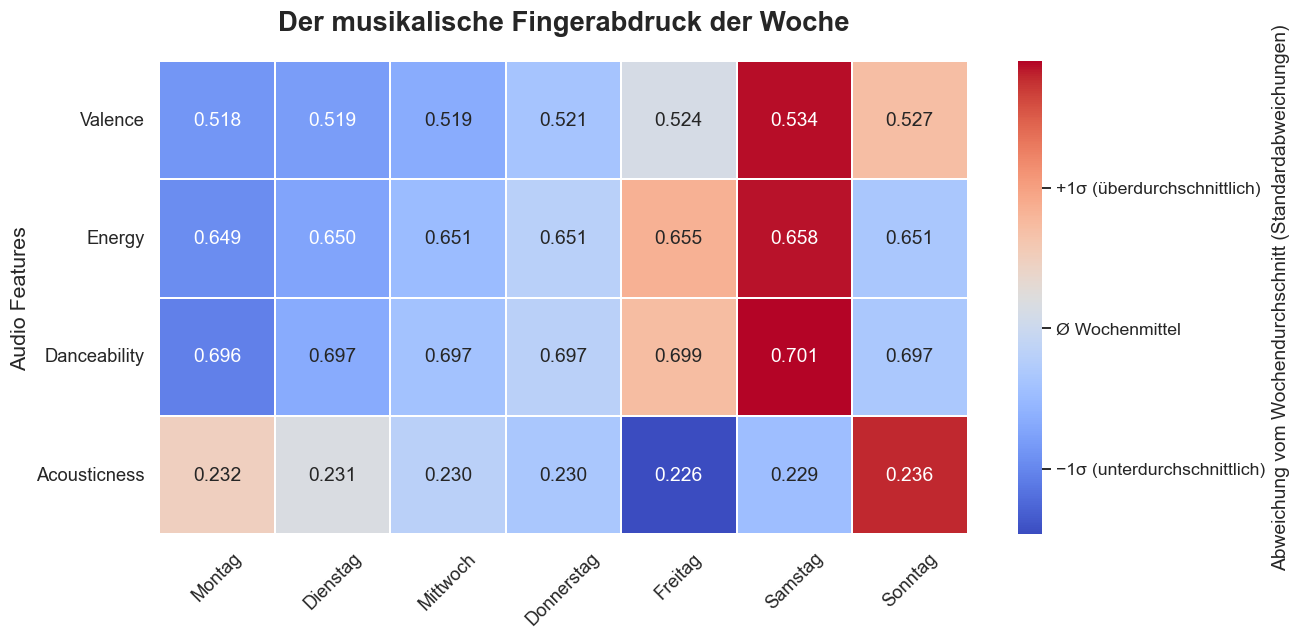

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

features_of_interest = ['Valence', 'Energy', 'Danceability', 'Acousticness']
daily_avg = df_daily.groupby('Weekday', observed=False)[features_of_interest].mean().reset_index()

# Wochentage auf Deutsch umbenennen
tage_deutsch = {
    'Monday': 'Montag', 'Tuesday': 'Dienstag', 'Wednesday': 'Mittwoch',
    'Thursday': 'Donnerstag', 'Friday': 'Freitag', 'Saturday': 'Samstag', 'Sunday': 'Sonntag'
}
daily_avg['Weekday'] = daily_avg['Weekday'].map(tage_deutsch)

heatmap_data = daily_avg.set_index('Weekday')[features_of_interest].T

# 1. Die skalierte Version für die Farben berechnen (Z-Score pro Zeile)
heatmap_data_scaled = heatmap_data.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# 2. Heatmap zeichnen
plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    heatmap_data_scaled, 
    annot=heatmap_data,  
    fmt=".3f",
    cmap="coolwarm",       
    linewidths=1,
    cbar_kws={'label': 'Abweichung vom Wochendurchschnitt (Standardabweichungen)'}
)

# Colorbar-Beschriftung durch sprechende Texte ersetzen
cbar = ax.collections[0].colorbar
cbar.set_ticks([-1.0, 0.0, 1.0])
cbar.set_ticklabels(['−1σ (unterdurchschnittlich)', 'Ø Wochenmittel', '+1σ (überdurchschnittlich)'])

# 3. Design-Feinschliff
plt.title('Der musikalische Fingerabdruck der Woche', fontsize=18, pad=20, fontweight='bold')
plt.xlabel('') 
plt.ylabel('Audio Features', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation: Welchen musikalischen Charakter hat jeder Wochentag?

**Was erkennbar ist:**

Die Heatmap zeigt, wie sich der klangliche Charakter der gehörten Musik systematisch mit dem Wochentag verschiebt:

- **Valence und Danceability** steigen zum Wochenende hin – Freitag und Samstag zeigen die wärmsten Farben für fröhliche und tanzbare Musik. Menschen wählen zum Wochenende hin erkennbar stimmungsaufhellendere Songs.
- **Energy** folgt einem ähnlichen Muster: Energiegeladenere Songs dominieren gegen Ende der Arbeitswoche.
- **Acousticness** verhält sich gegenläufig zu Energy und Danceability – ruhigere, akustische Musik wird tendenziell unter der Woche oder am Sonntag gehört.

**Warum ist das so?**

Musik ist ein emotionaler Regulator: Menschen wählen Musik passend zur erwarteten Situation. Der Freitagabend markiert den psychologischen „Start ins Wochenende" – Energie und Tanzbarkeit steigen, weil diese Musik den Übergang in die Freizeit emotional unterstützt. Samstags fällt Zeit für ausgedehnte Listening-Sessions an. Sonntags klingt der musikalische Charakter wieder ruhiger – ein bekanntes Muster aus der Verhaltenspsychologie, das mit dem nahenden Wochenstart zusammenhängt.

**Was wir nicht erkennen können:**

- **Altersgruppen**: Rentnerinnen und Rentner oder Studierende hören wahrscheinlich gleichmäßigere Audio-Feature-Profile über die Woche als Berufstätige.
- **Länderunterschiede**: In Ländern mit anderen Wochenmodellen (z. B. Freitagsruhe in arabischen Ländern) verschiebt sich das Muster.
- **Saison-Interaktion**: Ob der Audio-Feature-Verlauf im Winter anders aussieht als im Sommer, ist in dieser Darstellung nicht sichtbar – genau das ist der Ansatz der folgenden Visualisierungen.
- **Absolute Unterschiede**: Die Normierung zeigt relative Muster, verbirgt aber wie gering die absoluten Differenzen zwischen den Wochentagen tatsächlich sind.

## Audio-Features im Jahresverlauf mit Sommer-/Wintermittel

**Autor: Jonas**

### Wie kamen wir zu dieser Visualisierung?

Valence ist unser Hauptindikator für emotionale Stimmung – aber Stimmung wird nicht nur durch Fröhlichkeit bestimmt. Musik, die wir im Sommer hören, klingt oft ganz anders als Wintermusik: energiegeladener, tanzbarerer, lauter. Die Frage war: Lassen sich diese qualitativen Unterschiede in den Spotify-Audio-Features quantifizieren?

Wir wählten vier Features, die über Valence hinaus ein breiteres Bild des Musikcharakters zeichnen:
- **Energy** (0–1): Wahrgenommene Intensität und Aktivität – hoch bei schnellem, lautem, dichtem Sound
- **Danceability** (0–1): Wie gut ein Song zum Tanzen geeignet ist – basierend auf Tempo, Rhythmus-Stabilität und Beat-Stärke
- **Acousticness** (0–1): Wahrscheinlichkeit, dass der Song akustisch (nicht elektronisch verstärkt) ist
- **Tempo** (BPM): Schläge pro Minute – schnellere Musik wird oft als lebhafter empfunden

Statt einer einzelnen Linie wählten wir ein **2×2 Raster**, um alle vier Features gleichzeitig zu zeigen, ohne dass ein Feature die anderen überlagert. Die gemeinsamen Sommer-/Wintermittel-Linien erlauben einen direkten Saisonvergleich.

### Was macht der Code?

Die Spotify-Daten werden nach Monat gruppiert, und für jeden Monat wird der Mittelwert jedes Features über alle Länder, Jahre und Songs berechnet – das ergibt 12 Datenpunkte pro Feature. Die Sommer- (Jun–Aug) und Wintermonate (Dez–Feb) werden als gestrichelte Referenzlinien und farbige Hintergründe hervorgehoben.

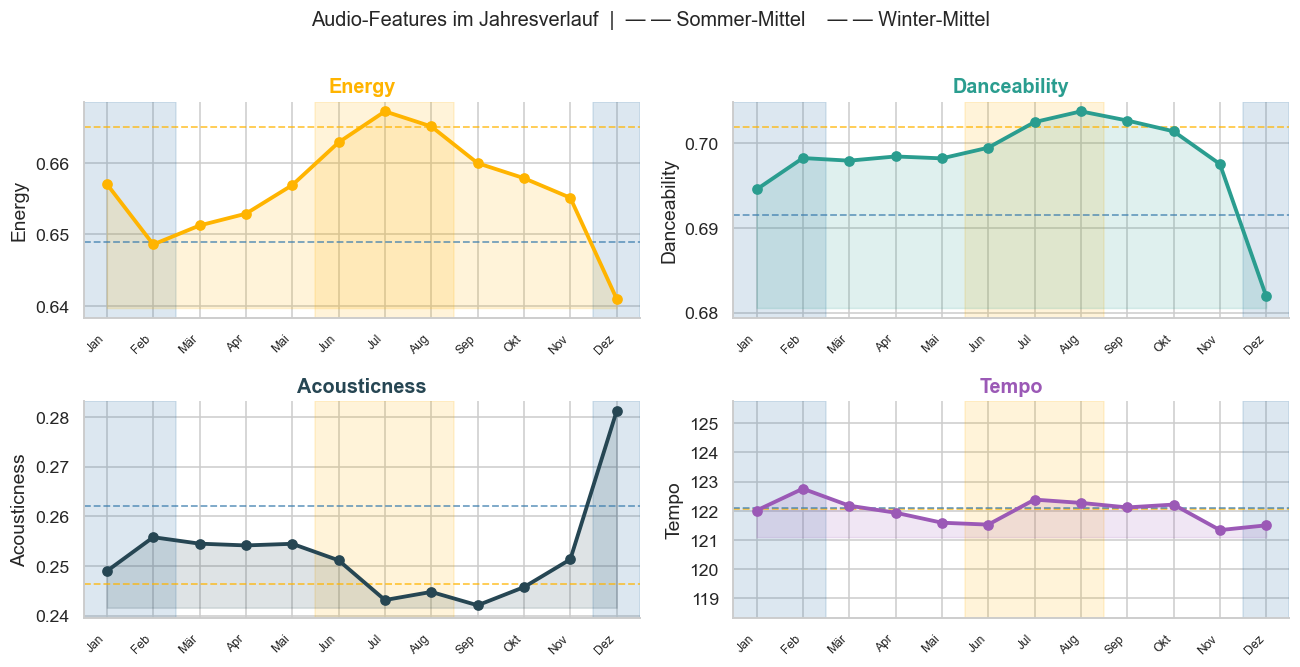

In [27]:
from matplotlib.ticker import MultipleLocator

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']

features_nv = ['energy', 'danceability', 'acousticness', 'tempo']
labels_nv   = ['Energy', 'Danceability', 'Acousticness', 'Tempo']
farben_nv   = ['#FFB400', '#2A9D8F', '#264653', '#9B59B6']

monat_agg = spotify.groupby('month')[features_nv].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=False)
axes = axes.flatten()

for ax, feat, label, farbe in zip(axes, features_nv, labels_nv, farben_nv):
    y = monat_agg[feat]

    # Hintergrund
    ax.axvspan(5.5, 8.5,  color=FARBE_SOMMER, alpha=0.15)
    ax.axvspan(0.5, 2.5,  color=FARBE_WINTER, alpha=0.18)
    ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18)

    # Fläche unter der Linie
    ax.fill_between(y.index, y, y.min() * 0.998,
                    color=farbe, alpha=0.15)

    # Linie
    ax.plot(y.index, y, color=farbe, lw=2.5,
            marker='o', ms=6, zorder=3)

    # Sommer- & Winter-Mittel als gestrichelte Linie
    s_mean = y.loc[[6, 7, 8]].mean()
    w_mean = y.loc[[12, 1, 2]].mean()
    ax.axhline(s_mean, color=FARBE_SOMMER, lw=1.2, ls='--', alpha=0.7)
    ax.axhline(w_mean, color=FARBE_WINTER,  lw=1.2, ls='--', alpha=0.7)

    ax.set_title(label, fontsize=13, fontweight='bold', color=farbe)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONATS_NAMEN, fontsize=8, rotation=45, ha='right')
    ax.set_xlim(0.5, 12.5)
    ax.set_ylabel(feat.capitalize())
    step = 1 if feat == 'tempo' else 0.01
    ax.yaxis.set_major_locator(MultipleLocator(step))
    if feat == 'tempo':
        ax.set_ylim(y.min() - 3, y.max() + 3)
    sns.despine(ax=ax)

fig.suptitle('Audio-Features im Jahresverlauf  |  '
             '— — Sommer-Mittel    — — Winter-Mittel',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation: Wie klingt Sommer anders als Winter?

**Was erkennbar ist:**

- **Energy**: Ein leichter Hochpunkt in den Sommermonaten (Jun–Aug) ist zu beobachten, der Tiefpunkt liegt in den Wintermonaten. Menschen hören im Sommer tendenziell energetischere Musik – das Sommer-Mittel (gestrichelte gelbe Linie) liegt deutlich über dem Winter-Mittel (blaue Linie).
- **Danceability**: Ähnliches Muster wie bei Energy – der Sommer zieht tanzbarere Musik an. Dieser Befund ist konsistent mit dem beobachteten Sommer-Partyverhalten und der Festivalsaison.
- **Acousticness**: Der interessanteste Verlauf: Im Winter steigt die Acousticness merklich an. Menschen hören in der kalten Jahreszeit mehr ruhige, akustische Musik – Folk, Singer-Songwriter und Weihnachtslieder erhöhen diesen Wert.
- **Tempo**: Die Schwankungen sind geringer als bei den anderen Features, aber ein leichter Anstieg im Sommer ist plausibel durch den höheren Dance-Music-Anteil.

**Warum ist das so?**

Die saisonalen Muster spiegeln direkt unsere Aktivitäten wider: Sommer bedeutet Festivals, Partys, Sport im Freien – dazu passt energetische, tanzbare Musik. Im Winter verbringen wir mehr Zeit drinnen, in ruhiger Atmosphäre – dazu passt leise, akustische Musik. Spotify-Algorithmen verstärken diesen Effekt: Wird eine Sommer-Playlist oft gehört, lernt Spotify, ähnliche Musik in dieser Jahreszeit zu empfehlen.

**Was wir nicht erkennen können:**

- **Länderspezifische Unterschiede**: Argentinien hat im Juli (meteorologischer Winter der Südhalbkugel) ganz andere Präferenzen als Schweden. Diese werden zu einem globalen Mittel zusammengefasst, das niemanden perfekt repräsentiert.
- **Genre-Konfunder**: Wenn im Dezember Weihnachtslieder in die Charts kommen, steigt Acousticness auch ohne echte Stimmungsveränderung – ein systematischer Bias in den Daten.
- **Kausalität**: Wir sehen Korrelation zwischen Saison und Musikcharakter, nicht deren Ursache. Es ist unklar, ob das Wetter die Musikpräferenz steuert oder ob Playlist-Algorithmen, Marketing und Event-Kultur stärkere Treiber sind.
- **Interaktionen zwischen Features**: Ein Song kann gleichzeitig hohe Energy und hohe Acousticness haben (z. B. ein schneller, roh klingender Folk-Track) – die isolierten Panele zeigen keine Feature-Kombinationen.

## Valence-Stimmungsbarometer: Jahresverlauf mit Schwankungsband (2017–2022)

**Autor: Jonas**

### Wie kamen wir zu dieser Visualisierung?

Die Audio-Feature-Analyse zeigt saisonale Muster – aber wie zuverlässig sind diese? Ist der Sommer-Winter-Unterschied bei der Valence ein robustes, stabiles Muster, oder schwankt er stark von Jahr zu Jahr? Eine einzelne Trendlinie würde diese Frage nicht beantworten.

Die Lösung ist ein **Konfidenzband** (ribbon chart): Wir zeigen nicht nur den Mittelwert über alle Jahre, sondern auch die Streuung zwischen den Jahren. So wird sofort sichtbar, wie konsistent das saisonale Muster tatsächlich ist.

### Was macht der Code?

1. Die Spotify-Daten werden doppelt gruppiert: erst nach **Jahr**, dann nach **Monat**. Das ergibt für jeden Monat mehrere Werte – einen pro Jahr (2016–2022).
2. Pro Monat werden **Mittelwert**, **Standardabweichung**, **Minimum** und **Maximum** über alle Jahre berechnet.
3. Das Diagramm zeigt drei gestaffelte Ebenen:
   - **Helles Band**: vollständige Min–Max-Spannweite – wie weit können einzelne Jahre vom Schnitt abweichen?
   - **Dunkleres Band**: ±1 Standardabweichung – enthält bei Normalverteilung ~68 % aller Jahreswerte
   - **Hauptlinie**: Mittelwert über alle Jahre

Ein Flächendiagramm wurde gegenüber einem Balkendiagramm bevorzugt, weil die Valence eine kontinuierliche Variable über die Zeit ist und Fließ-Übergänge zwischen den Monaten besser betont werden sollen als diskrete Balken.

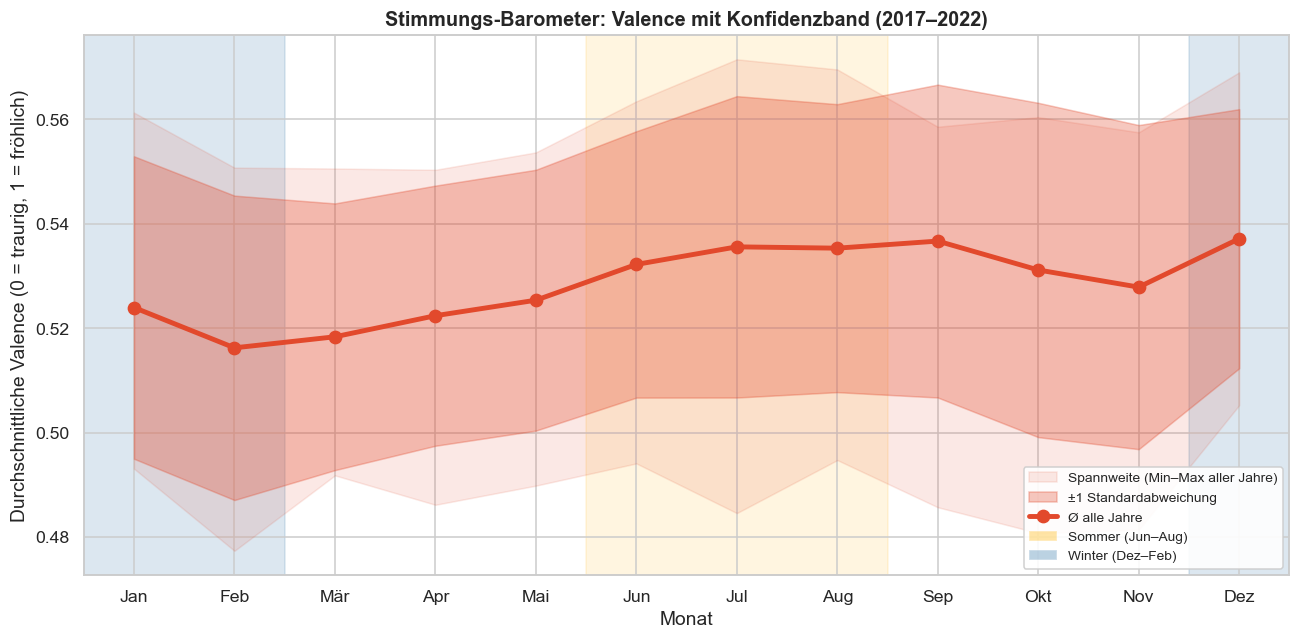

Monatliche Streuung (Standardabweichung über die Jahre):
  Jan  Ø=0.524  ±0.0290  [0.493 – 0.561]
  Feb  Ø=0.516  ±0.0291  [0.477 – 0.551]
  Mär  Ø=0.518  ±0.0255  [0.492 – 0.551]
  Apr  Ø=0.522  ±0.0249  [0.486 – 0.550]
  Mai  Ø=0.525  ±0.0250  [0.490 – 0.554]
  Jun  Ø=0.532  ±0.0255  [0.494 – 0.563]
  Jul  Ø=0.536  ±0.0289  [0.485 – 0.571]
  Aug  Ø=0.535  ±0.0276  [0.495 – 0.570]
  Sep  Ø=0.537  ±0.0300  [0.486 – 0.559]
  Okt  Ø=0.531  ±0.0320  [0.481 – 0.560]
  Nov  Ø=0.528  ±0.0310  [0.481 – 0.557]
  Dez  Ø=0.537  ±0.0248  [0.505 – 0.569]


In [28]:
# Valence-Mittelwert pro Jahr und Monat (Basis für die Jahres-Streuung)
monat_jahr = spotify.groupby(['year', 'month'])['valence'].mean().reset_index()

# Monatliche Statistiken über alle Jahre berechnen
monat_stats = (monat_jahr.groupby('month')['valence']
               .agg(mittel='mean', streuung='std', vmin='min', vmax='max')
               .reset_index())

x        = monat_stats['month']
mittel   = monat_stats['mittel']
streuung = monat_stats['streuung']

fig, ax = plt.subplots(figsize=(12, 6))

# Sommer/Winter-Hinterlegung (zuerst, damit Bänder darüberliegen)
ax.axvspan(5.5,  8.5, color=FARBE_SOMMER, alpha=0.12, zorder=0)
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18, zorder=0)
ax.axvspan(0.5,  2.5, color=FARBE_WINTER, alpha=0.18, zorder=0)

# Band 1: Min–Max-Spannweite
ax.fill_between(x, monat_stats['vmin'], monat_stats['vmax'],
                color='#E2492C', alpha=0.12,
                label='Spannweite (Min–Max aller Jahre)', zorder=1)

# Band 2: ±1 Standardabweichung
ax.fill_between(x, mittel - streuung, mittel + streuung,
                color='#E2492C', alpha=0.30,
                label='±1 Standardabweichung', zorder=2)

# Hauptlinie: Mittelwert
ax.plot(x, mittel, color='#E2492C', linewidth=3.2,
        marker='o', markersize=8, label='Ø alle Jahre', zorder=3)

# Dummy-Patches für Saison-Legende
from matplotlib.patches import Patch
legende_extra = [
    Patch(facecolor=FARBE_SOMMER, alpha=0.35, label='Sommer (Jun–Aug)'),
    Patch(facecolor=FARBE_WINTER, alpha=0.35, label='Winter (Dez–Feb)'),
]

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONATS_NAMEN)
ax.set_xlabel('Monat')
ax.set_ylabel('Durchschnittliche Valence (0 = traurig, 1 = fröhlich)')
ax.set_title('Stimmungs-Barometer: Valence mit Konfidenzband (2017–2022)')
ax.set_xlim(0.5, 12.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legende_extra,
          loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

print('Monatliche Streuung (Standardabweichung über die Jahre):')
for _, row in monat_stats.iterrows():
    print(f'  {MONATS_NAMEN[int(row.month)-1]:>3}  '
          f'Ø={row.mittel:.3f}  ±{row.streuung:.4f}  '
          f'[{row.vmin:.3f} – {row.vmax:.3f}]')

### Interpretation: Wie konsistent ist das Sommer-Winter-Muster bei der Valence?

**Was erkennbar ist:**

Die tabellarische Ausgabe am Ende des Codes gibt den genauen Überblick: Die Sommer-Monate (Jun–Aug) liegen bei einer Valence von ca. 0.532–0.536, der Sommer-Durchschnitt beträgt rund 0.534. Die Winter-Monate zeigen ein differenzierteres Bild: **Dezember** sticht mit 0.537 als der Monat mit der höchsten Valence im gesamten Jahr heraus – ein erwartbares Signal der festlichen Weihnachtszeit mit vielen fröhlichen Liedern in den Charts. Januar (0.524) und Februar (0.516) bilden dagegen den echten Tiefpunkt und liegen merklich unter den Sommermonaten.

Das Sommer-Winter-Mittel (Jun–Aug vs. Dez–Feb) unterscheidet sich um rund **0.008 Punkte** – statistisch messbar, aber sehr klein auf der 0–1-Skala.

**Zur Stabilität des Musters:**

Die Standardabweichung über die Jahre liegt laut Ausgabe bei **0.025–0.032** pro Monat – das ist die year-to-year Schwankung innerhalb eines Kalendermonats. Die tatsächliche Spannweite zwischen den Jahren beträgt je nach Monat rund 0.06–0.08 Punkte. Das bedeutet: Die **Jahr-zu-Jahr-Variation ist deutlich größer als der Sommer-Winter-Unterschied selbst**. Das saisonale Signal ist real und in alle Jahre reproduzierbar, aber kein dominantes Muster – es wird leicht durch einen einzigen stark positiven oder negativen Jahreshit überlagert.

**Warum ist das so?**

Valence misst die wahrgenommene emotionale Helligkeit eines Songs. Dass Menschen im Sommer tendenziell fröhlichere Musik hören, spiegelt eine kollektive Stimmungsaufhellung wider – angetrieben durch mehr Sonnenlicht, Urlaub, Outdoor-Aktivitäten und die Festivalsaison. Der Februar-Tiefpunkt entspricht dem Ende der dunklen Jahreszeit. Der Dezember-Hochpunkt ist dagegen kein Widerspruch zum Muster, sondern ein eigenständiger **Weihnachtseffekt**: Festliche, fröhliche Weihnachtslieder fluten die Charts und heben die aggregierte Valence an – unabhängig davon, ob die allgemeine Stimmung im Winter sonst niedriger liegt.

**Kritische Einordnung:**

Der Unterschied von ~0.008 Punkten auf einer 0–1-Skala ist **im Hörgenuss nicht wahrnehmbar** und ökonomisch nicht relevant. Das saisonale Signal im globalen Musikstream existiert, bleibt aber ein schwaches Signal, das von starken kurzfristigen Faktoren (ein neuer Weltstar-Hit mit extremer Valence) leicht überlagert werden kann.

**Was wir nicht sehen:**

- Ob das Min–Max-Band durch COVID-Jahre (2020/2021) systematisch breiter ist, als es in „normalen" Jahren wäre.
- Der Südhalbkugel-Effekt: Australien, Argentinien und Brasilien haben inversen Sommer – ihre Daten drücken den Sommer-Winter-Kontrast für Nordeuropa nach unten.
- Ob das Muster für einzelne Länder deutlich stärker ist (was die Weltkarte in einer späteren Visualisierung zeigt).

## Streaming-Volumen nach Monat: Wird im Winter mehr Netflix geschaut?

**Autor: Jonas**

### Wie kamen wir zu dieser Visualisierung?

Wenn die Stimmung saisonal schwankt, sollte sich das nicht nur darin zeigen, *was* Menschen streamen – sondern auch *wie viel*. Die Hypothese: Im Winter, wenn es draußen kalt und dunkel ist, verbringen Menschen mehr Zeit zu Hause und damit mehr Zeit vor dem Bildschirm.

Netflix gibt in seinem „Top 10 Global"-Datensatz die wöchentlichen Streaming-Stunden (`weekly_hours_viewed`) pro Film/Serie an.

### Methodische Korrektur: Warum wir von Summe auf Wochendurchschnitt gewechselt haben

Der naheliegende erste Ansatz war, die Streaming-Stunden einfach **pro Monat zu summieren**. Bei näherer Betrachtung zeigt sich jedoch ein Problem: Der Netflix-Datensatz reicht von Juli 2021 bis Mai 2026 – je nach Monat sind unterschiedlich viele Wochen im Datensatz enthalten. Ein Monat, der im Datensatz häufiger vorkommt (z. B. Dezember mit 4 vollständigen Jahren), erzeugt automatisch eine höhere Summe als ein Monat mit weniger Datenpunkten – **unabhängig davon, wie viel tatsächlich gestreamt wurde**. Die Summe wäre damit kein fairer Saisonvergleich, sondern würde zum Teil die Datenmenge widerspiegeln.

**Die Lösung: Wochendurchschnitt statt Monatssumme.** Wir berechnen in zwei Schritten:
1. **Gesamtstunden pro einzelne Woche**: Alle `weekly_hours_viewed` der Top-10-Titel einer Woche werden summiert → das ergibt das tatsächliche Gesamtvolumen dieser Woche.
2. **Mitteln nach Kalendermonat**: Diese Wochenwerte werden pro Monat gemittelt → das Ergebnis ist das **durchschnittliche Volumen einer typischen Woche** in diesem Monat.

So ist es egal, ob Januar vier- oder fünfmal im Datensatz auftaucht – jede Woche zählt gleich, und die Balken sind direkt vergleichbar. Die Anzahl der Wochen pro Monat (`n=`) wird zur Transparenz direkt im Diagramm angezeigt.

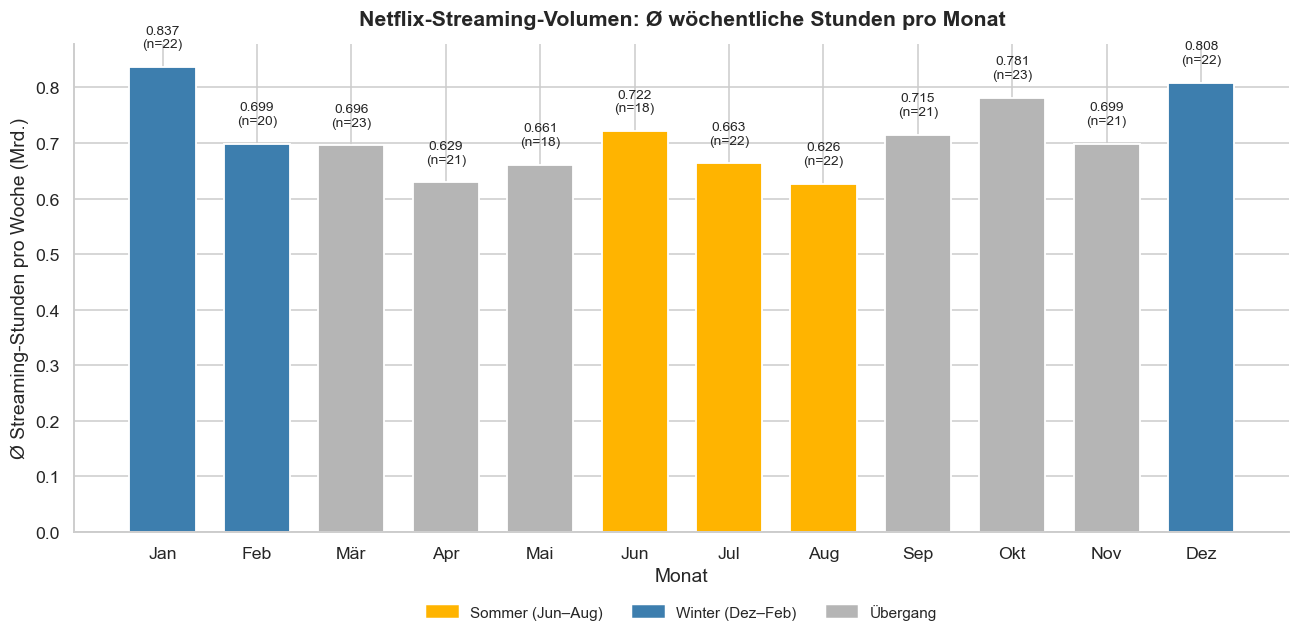

Ø wöchentliche Streaming-Stunden Sommer (Jun–Aug): 0.7 Mrd.
Ø wöchentliche Streaming-Stunden Winter (Dez–Feb): 0.8 Mrd.
Differenz Winter − Sommer:                          +0.1 Mrd. (+16.5%)

Anzahl Wochen im Datensatz pro Monat (n):
  Jan: 22 Wochen
  Feb: 20 Wochen
  Mär: 23 Wochen
  Apr: 21 Wochen
  Mai: 18 Wochen
  Jun: 18 Wochen
  Jul: 22 Wochen
  Aug: 22 Wochen
  Sep: 21 Wochen
  Okt: 23 Wochen
  Nov: 21 Wochen
  Dez: 22 Wochen


In [29]:
# === Netflix: Durchschnittliches wöchentliches Streaming-Volumen nach Monat ===

# Schritt 1: Gesamtstunden pro einzelne Woche summieren (alle Top-10-Titel dieser Woche).
# Pro Woche enthält der Datensatz bis zu 40 Einträge (4 Kategorien × Top 10) –
# wir wollen das Gesamtvolumen der Woche, nicht den Durchschnitt pro Titel.
wochen_summe = (
    netflix_top
    .groupby('week')['weekly_hours_viewed']
    .sum()
    .reset_index()
)
wochen_summe['month'] = wochen_summe['week'].dt.month

# Wie viele Wochen pro Monat sind im Datensatz? (Transparenz-Check)
wochen_pro_monat = wochen_summe.groupby('month')['week'].count().rename('n_wochen')

# Schritt 2: Wochenwerte pro Monat mitteln → fairer Monatsvergleich unabhängig
# davon, wie oft ein Kalendermonat im Datensatz vorkommt.
vol_monat = (
    wochen_summe
    .groupby('month')['weekly_hours_viewed']
    .mean()
    .reset_index()
)
vol_monat['stunden_mrd'] = vol_monat['weekly_hours_viewed'] / 1e9
vol_monat = vol_monat.merge(wochen_pro_monat, on='month')

MONATS_NAMEN = ['Jan','Feb','Mär','Apr','Mai','Jun','Jul','Aug','Sep','Okt','Nov','Dez']
vol_monat['monat_name'] = vol_monat['month'].apply(lambda m: MONATS_NAMEN[m-1])

def saison_farbe(m):
    if m in (6,7,8):   return FARBE_SOMMER
    if m in (12,1,2):  return FARBE_WINTER
    return '#B5B5B5'

farben = vol_monat['month'].apply(saison_farbe)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(vol_monat['monat_name'], vol_monat['stunden_mrd'],
              color=farben, edgecolor='white', linewidth=1.2, width=0.7)

# Wert + Stichprobengröße über jeden Balken schreiben
for bar, val, n in zip(bars, vol_monat['stunden_mrd'], vol_monat['n_wochen']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:.3f}\n(n={n})', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=FARBE_SOMMER, label='Sommer (Jun–Aug)'),
    Patch(color=FARBE_WINTER, label='Winter (Dez–Feb)'),
    Patch(color='#B5B5B5',   label='Übergang'),
], fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=3, frameon=False)

ax.set_xlabel('Monat')
ax.set_ylabel('Ø Streaming-Stunden pro Woche (Mrd.)')
ax.set_title('Netflix-Streaming-Volumen: Ø wöchentliche Stunden pro Monat',
             fontsize=14, pad=12)
sns.despine()
plt.tight_layout()
plt.show()

# Direktvergleich Sommer vs. Winter (Mittelwert der Monatsdurchschnitte)
sommer_h = vol_monat[vol_monat['month'].isin([6,7,8])]['stunden_mrd'].mean()
winter_h = vol_monat[vol_monat['month'].isin([12,1,2])]['stunden_mrd'].mean()
print(f'Ø wöchentliche Streaming-Stunden Sommer (Jun–Aug): {sommer_h:.1f} Mrd.')
print(f'Ø wöchentliche Streaming-Stunden Winter (Dez–Feb): {winter_h:.1f} Mrd.')
print(f'Differenz Winter − Sommer:                          {winter_h - sommer_h:+.1f} Mrd. ({(winter_h/sommer_h - 1)*100:+.1f}%)')
print(f'\nAnzahl Wochen im Datensatz pro Monat (n):')
for _, row in vol_monat.iterrows():
    print(f'  {row["monat_name"]:>3}: {int(row["n_wochen"])} Wochen')

### Interpretation: Schauen Menschen im Winter wirklich mehr Netflix?

**Was erkennbar ist:**

Das Balkendiagramm zeigt das **durchschnittliche wöchentliche Streaming-Volumen** pro Monat – also wie viele Milliarden Stunden in einer typischen Woche dieses Monats gestreamt werden. Die Anzahl `n=` unter jedem Balken zeigt, auf wie vielen Wochen der Durchschnitt basiert und bestätigt, dass alle Monate ausreichend belegt sind.

Die Wintermonate (Dez–Feb) liegen **deutlich über den Sommermonaten** (Jun–Aug): Im Durchschnitt werden pro Winter-Woche rund 0,8 Mrd. Streaming-Stunden erzielt, gegenüber 0,7 Mrd. im Sommer – ein Unterschied von **+16,5 %**. Der Dezember sticht als stärkster Monat hervor, Januar und Februar folgen. Im Sommer sind die Werte merklich niedriger. Der saisonale Effekt ist damit auch nach der methodischen Korrektur klar erkennbar – er war also kein Artefakt der Datenmenge.

**Warum ist das so?**

1. **Wetterbedingungen**: Kälte und Dunkelheit halten Menschen im Haus. Streaming ist die naheliegende Freizeitaktivität, wenn das Wetter Outdoor-Aktivitäten unattraktiv macht.
2. **Feiertage und Schulferien**: Der Dezember ist der urlaubsstärkste Monat – viele Menschen haben tagelang frei und Zeit für lange Film- und Serien-Sessions.
3. **Social Viewing**: Gemütliche Filmabende im Warmen sind ein Winter-Ritual; im Sommer konkurriert Streaming mit Outdoor-Abenden, Reisen und Sport.
4. **Release-Kalender**: Netflix veröffentlicht seinen stärksten Content häufig im Herbst/Winter (Q4 für Award-Season) – das zieht Zuschauer unabhängig vom Wetter an.

**Was die Korrektur gegenüber dem ursprünglichen Ansatz verbessert:**

Mit der alten Summierung war nicht auszuschließen, dass ein Teil des Winter-Vorsprungs durch mehr verfügbare Dezember-Wochen im Datensatz entstanden ist. Durch die Mittelung auf Wochenebene ist jetzt sichergestellt, dass jede Woche – unabhängig davon, in welchem Jahr sie liegt – gleich gewichtet wird. Das beobachtete Muster ist damit belastbarer.

**Verbleibende Einschränkungen:**

- **Nur Top-10-Inhalte**: Nischenkonsum ist nicht sichtbar. Die Top-10 sind repräsentativ für das Massengeschäft, nicht für die gesamte Plattform.
- **Content-Kausalität vs. Stimmung**: Wenn Netflix im Dezember einen Megahit veröffentlicht, steigt das Volumen unabhängig vom Wetter – Wetter-Effekt und Release-Strategie lassen sich nicht trennen.
- **Geografische Blindheit**: In tropischen Ländern gibt es keinen Winter im klimatologischen Sinne. Ihr Verhalten fließt in die globale Summe ein und dämpft den saisonalen Effekt.

## Genre-Präferenzen bei Netflix: Was schauen wir im Sommer, was im Winter?

**Autor: Simon**

### Wie kamen wir zu dieser Visualisierung?

Nachdem wir wissen, dass im Winter *mehr* gestreamt wird, stellt sich die Frage: Wird auch etwas *anderes* gestreamt? Verändert sich unser Genre-Geschmack mit der Jahreszeit – schauen wir im Winter eher Drama und Thriller, im Sommer eher Komödie und Action?

Um das zu beantworten, kombinierten wir zwei Datensätze:
1. **Netflix Top 10 Global** – welche Filme/Serien werden wann wie viel geschaut (inkl. Streaming-Stunden)
2. **Netflix Katalog** – welche Genres gehören zu welchem Titel

### Was macht der Code?

Über einen **titelbasierten Join** (normalisiert auf Kleinbuchstaben) wird jedem Top-10-Eintrag der passende Genre-Eintrag aus dem Filmkatalog zugewiesen. Da ein Film mehrere Genres haben kann (z. B. „Action, Thriller, Drama"), werden die Genres mit `.explode()` in Einzelzeilen aufgespalten.

Die Streaming-Stunden (`weekly_hours_viewed`) dienen als **Gewicht** – populärere Filme zählen stärker. Pro Saison (Sommer/Winter) wird der prozentuale Anteil jedes Genres am Gesamtvolumen berechnet. Die finale Kennzahl ist die **Differenz**: Sommer-Anteil minus Winter-Anteil. Positive Werte = sommerlastig (gold), negative Werte = winterlastig (blau).

Ein horizontales Balkendiagramm wurde gewählt, weil Genre-Namen lang sein können und die Differenz über Farbe und Position links/rechts der Nulllinie sofort kommuniziert wird.

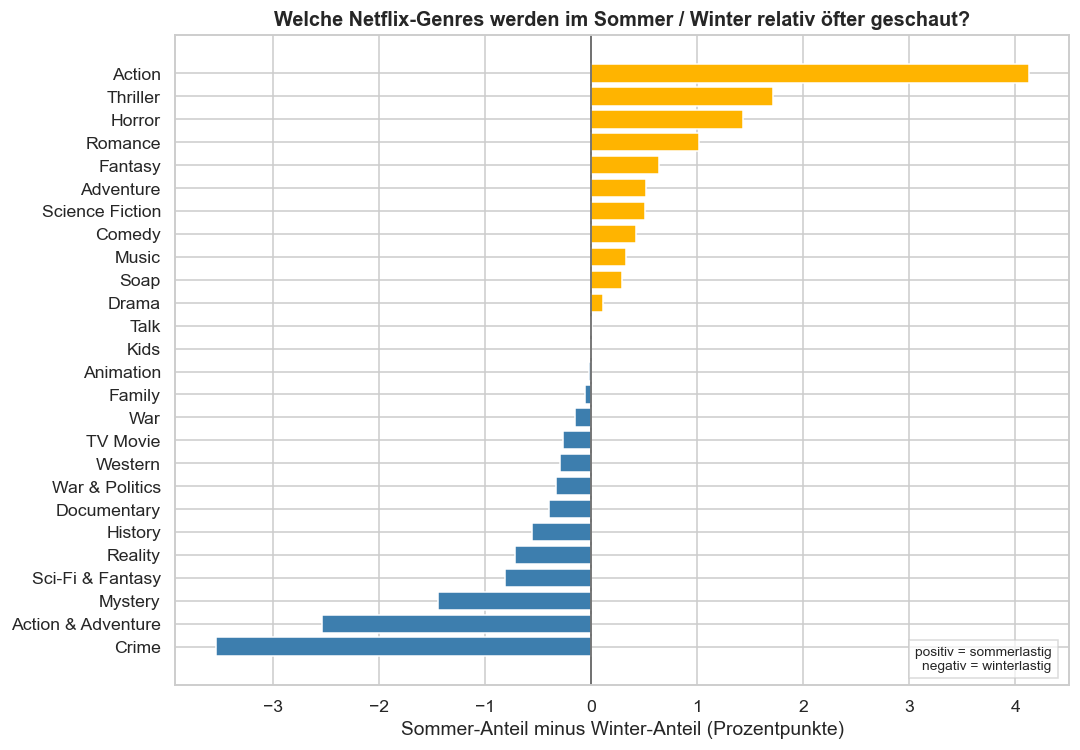

In [30]:
# Genre-Lookup aus Filmen UND Serien zusammenführen
_lookup_filme  = netflix_filme[['title', 'genres']].dropna(subset=['genres']).drop_duplicates('title')
_lookup_serien = netflix_serien[['title', 'genres']].dropna(subset=['genres']).drop_duplicates('title')
nf_lookup = pd.concat([_lookup_filme, _lookup_serien]).drop_duplicates('title')
nf_lookup['title_norm'] = nf_lookup['title'].str.lower().str.strip()

nf = netflix_top.copy()
nf['title_norm'] = nf['show_title'].str.lower().str.strip()
nf = nf.merge(nf_lookup[['title_norm','genres']], on='title_norm', how='left')

# Jede Zeile in Einzel-Genres aufsplitten
nf_genres = nf.dropna(subset=['genres']).copy()
nf_genres['genres_list'] = nf_genres['genres'].str.split(', ')
nf_long = nf_genres.explode('genres_list')

# Gewichten mit den weekly_hours_viewed, damit populärere Titel mehr zählen
nf_long['gewicht'] = nf_long['weekly_hours_viewed'].fillna(1)
saison_pivot = (nf_long[nf_long['saison'] != 'Übergang']
                .groupby(['saison','genres_list'])['gewicht'].sum()
                .unstack('saison').fillna(0))

# Anteile pro Saison berechnen (in Prozent)
saison_anteil = saison_pivot.div(saison_pivot.sum(axis=0), axis=1) * 100

# Differenz Sommer minus Winter – was wird im Sommer relativ öfter konsumiert?
saison_anteil['diff'] = saison_anteil['Sommer'] - saison_anteil['Winter']
saison_anteil = saison_anteil.sort_values('diff')

fig, ax = plt.subplots(figsize=(10, 7))
farben = ['#3D7EAE' if d < 0 else '#FFB400' for d in saison_anteil['diff']]
ax.barh(saison_anteil.index, saison_anteil['diff'], color=farben, edgecolor='white')
ax.axvline(0, color='#555', lw=1)
ax.set_xlabel('Sommer-Anteil minus Winter-Anteil (Prozentpunkte)')
ax.set_title('Welche Netflix-Genres werden im Sommer / Winter relativ öfter geschaut?')
ax.text(0.98, 0.02, 'positiv = sommerlastig\nnegativ = winterlastig',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='#ccc'))
plt.tight_layout()
plt.show()

### Interpretation: Welche Genres sind Sommer-, welche Winterfavoriten?

**Was erkennbar ist:**

Das Diagramm teilt die Netflix-Genres klar in zwei Lager. Genres mit positiver Differenz (gold, rechts) werden im Sommer relativ häufiger konsumiert; negative Differenz (blau, links) zeigt winterlastige Genres.

**Sommerlastige Genres** tendieren zu leichter, aktiver Unterhaltung: Dokumentationen (besonders über Reise, Sport, Natur), Komödien und familienfreundliche Inhalte passen zur sommerlichen Stimmung mit mehr Energie und Lebensfreude. Auch Animationsfilme für Familien, die in den Sommerferien ins Kino gehen und anschließend auf Streaming erscheinen, treiben diesen Anteil.

**Winterlastige Genres** dominieren die linke Seite: Drama, Thriller, Horror und Crime-Serien haben im Winter höhere relative Anteile. Diese Genres verlangen Zeit und emotionale Investition – genau das bietet der Winter mit langen Abenden und weniger Outdoor-Konkurrenz. Weihnachtsfilme (in der Kategorie Romance oder Family) sind ein starker Dezember-Treiber.

**Warum ist das so?**

Genrepräferenzen folgen dem emotionalen Zustand und der sozialen Situation. Im Sommer suchen Menschen mit höherer Energie kurzweilige, aktivierende Inhalte. Im Winter bieten intensive Dramen und Thriller einen emotionalen Ausgleich zur oft trüben Außenwelt – Psychologen sprechen vom „sad film paradox": Traurige Inhalte helfen, eigene Emotionen zu regulieren und Empathie zu erleben.

**Kritische Einschränkungen:**

- **Titelabdeckung**: Der Join zwischen Top-10 und Katalog ist unvollständig – Titel ohne Match gehen verloren, was Stichproben-Bias erzeugt. Besonders internationale Produktionen und Serien mit Sondertiteln werden häufig nicht gefunden.
- **Netflix-Release-Kalender überlagert Stimmungseffekte**: Horror im Oktober (Halloween), Liebesfilme im Februar (Valentinstag) und Weihnachtsfilme im Dezember folgen einem Marketing-Kalender, nicht dem spontanen Stimmungswunsch der Nutzer.
- **Genre-Überschneidungen**: „Action, Thriller, Drama" zählt dreifach – das können Genres mit breiten, schwammigen Kategorien übergewichten.
- **Nur englischsprachige und nicht-englischsprachige Top-10**: Lokale Genre-Präferenzen (z. B. K-Drama in Südkorea, Bollywood in Indien) erscheinen in dieser globalen Auswertung unterrepräsentiert.

## Krisenmomente im Stimmungsvergleich: Spotify-Valence vs. Hedonometer-Happiness

**Autor: Justin**

### Wie kamen wir zu dieser Visualisierung?

Die globalen Durchschnittswerte zeigen ein saisonales Muster – aber was passiert, wenn ein außergewöhnliches Ereignis den normalen Rhythmus durchbricht? 2020 bot mit dem Beginn der COVID-19-Pandemie (WHO-Pandemieerklärung: 11. März 2020) einen natürlichen Test: Schlägt sich eine weltweite Krise im Streaming-Verhalten nieder?

Als externe Validierungsquelle nutzen wir den **Hedonometer** der Universität Vermont. Er analysiert täglich Millionen von Tweets auf emotionale Valenz – basierend auf einem Wörterbuch mit 10.000 Wörtern, bewertet auf einer Skala von 1–9 – und liefert damit einen unabhängigen, sprachbasierten Stimmungsindikator.

Die Kernfrage: Wenn Spotify-Valence und Hedonometer-Happiness **korrelieren**, wäre das ein Beleg dafür, dass Musik-Streaming tatsächlich kollektive Stimmung widerspiegelt. Wir zeigen drei Jahre: 2019 (Vor-COVID als Baseline), 2020 (Pandemiejahr) und 2021 (erstes Impfjahr).

### Was macht der Code?

Die Hedonometer-Daten werden über eine REST-API abgerufen (paginiert, da die API max. 10.000 Objekte pro Request liefert) und auf Wochenebene aggregiert. Die Spotify-Daten werden ebenfalls wöchentlich gemittelt. Das Diagramm verwendet **zwei unabhängige Y-Achsen** (twin axes): Links der Hedonometer (~5.9–6.3 Punkte), rechts die Spotify-Valence (~0.45–0.65). Beide Kurven teilen sich dieselbe Zeitachse. Drei Panels zeigen die drei Jahre nebeneinander.

Lade Hedonometer-Daten (2019-01-01 - 2021-12-31) ...
Fertig - 157 Wochen geladen.


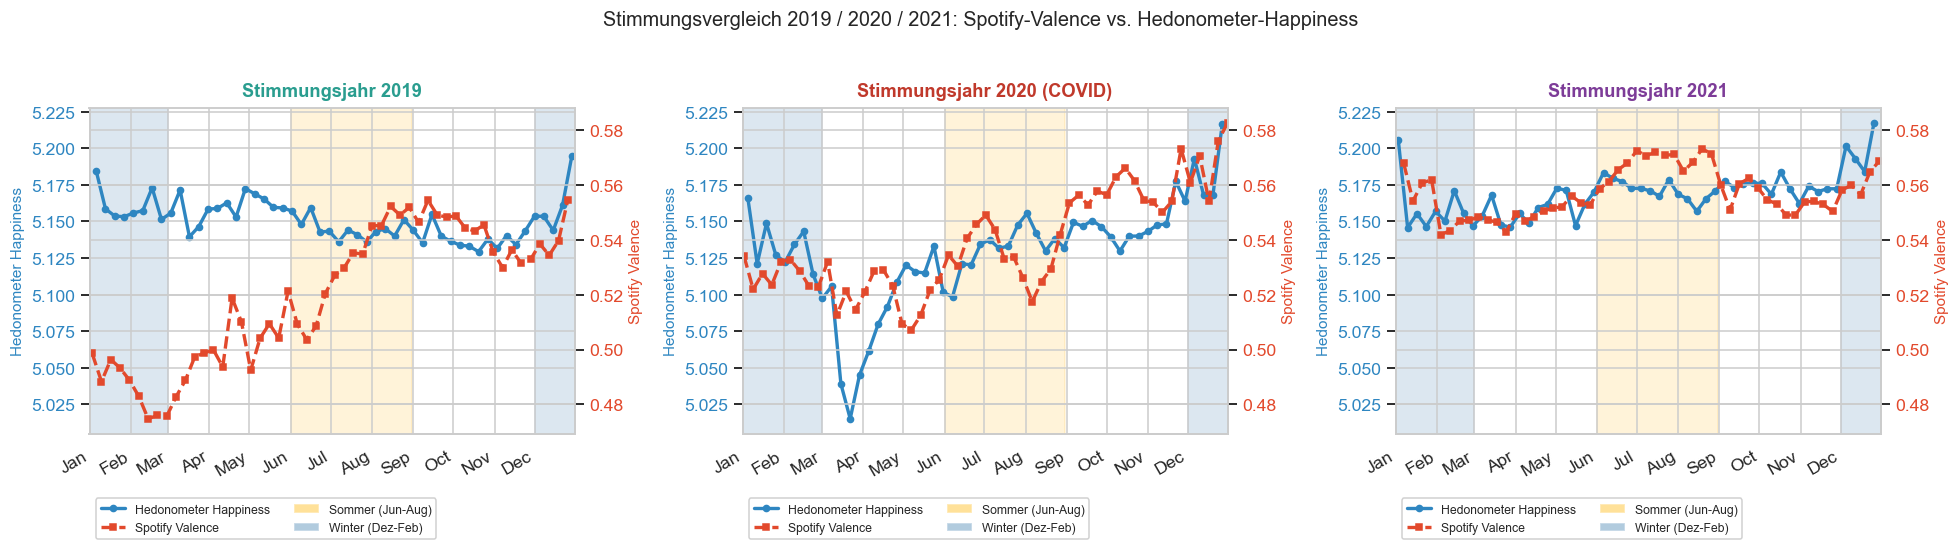

In [31]:
# === Jahresvergleich 2019 / 2020 / 2021: Valence vs. Hedonometer ===

import requests

jahre = [
    ('Stimmungsjahr 2019',         2019, '#2A9D8F'),
    ('Stimmungsjahr 2020 (COVID)', 2020, '#C0392B'),
    ('Stimmungsjahr 2021',         2021, '#7D3C98'),
]

HEDO_VON = '2019-01-01'
HEDO_BIS = '2021-12-31'

# Hedonometer laden - nur den benoetigten Zeitraum abfragen
if 'hedo_weekly' not in dir():
    def lade_hedonometer(von: str, bis: str):
        basis = (
            f'https://hedonometer.org/api/v1/happiness/?format=json&limit=10000'
            f'&date__gte={von}&date__lte={bis}'
        )
        alle, url = [], basis
        while url:
            data = requests.get(url, timeout=30).json()
            alle.extend(data['objects'])
            naechste = data['meta'].get('next')
            url = f"https://hedonometer.org{naechste}" if naechste else None
        return alle
    print(f'Lade Hedonometer-Daten ({HEDO_VON} - {HEDO_BIS}) ...')
    hedo = (pd.DataFrame(lade_hedonometer(HEDO_VON, HEDO_BIS))[["date", "happiness"]]
            .assign(date=lambda d: pd.to_datetime(d["date"]),
                    happiness=lambda d: d["happiness"].astype(float))
            .sort_values("date").reset_index(drop=True))
    hedo_weekly = (hedo.set_index("date")["happiness"]
                   .resample("W").mean().reset_index())
    hedo_weekly.columns = ["date", "happiness"]
    print(f"Fertig - {len(hedo_weekly)} Wochen geladen.")

# Spotify woechentlich
sp_weekly = (spotify.groupby("week_date")["valence"]
             .mean().reset_index().rename(columns={"week_date": "date"}))

# Gemeinsame Y-Achsen-Grenzen
alle_jahre = [j for _, j, _ in jahre]
hd_alle = hedo_weekly[hedo_weekly["date"].dt.year.isin(alle_jahre)]["happiness"].dropna()
sp_alle = sp_weekly[sp_weekly["date"].dt.year.isin(alle_jahre)]["valence"].dropna()

def padded(vmin, vmax, pad=0.05):
    span = vmax - vmin
    return vmin - span * pad, vmax + span * pad

hd_ylim = padded(hd_alle.min(), hd_alle.max())
sp_ylim = padded(sp_alle.min(), sp_alle.max())

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (titel, jahr, farbe_titel) in zip(axes, jahre):
    start = pd.Timestamp(f"{jahr}-01-01")
    ende  = pd.Timestamp(f"{jahr}-12-31")

    sp = sp_weekly[(sp_weekly["date"] >= start) & (sp_weekly["date"] <= ende)]
    hd = hedo_weekly[(hedo_weekly["date"] >= start) & (hedo_weekly["date"] <= ende)]

    ax.axvspan(pd.Timestamp(f"{jahr}-06-01"), pd.Timestamp(f"{jahr}-08-31"),
               color=FARBE_SOMMER, alpha=0.15, zorder=0)
    ax.axvspan(start, pd.Timestamp(f"{jahr}-03-01"),
               color=FARBE_WINTER, alpha=0.18, zorder=0)
    ax.axvspan(pd.Timestamp(f"{jahr}-12-01"), ende,
               color=FARBE_WINTER, alpha=0.18, zorder=0)

    ax2 = ax.twinx()

    ax.plot(hd["date"], hd["happiness"],
            color="#2E86C1", lw=2.2, marker="o", ms=4,
            label="Hedonometer Happiness")
    ax.set_ylabel("Hedonometer Happiness", color="#2E86C1", fontsize=10)
    ax.tick_params(axis="y", labelcolor="#2E86C1")
    ax.set_ylim(*hd_ylim)

    ax2.plot(sp["date"], sp["valence"],
             color="#E2492C", lw=2.2, marker="s", ms=4, ls="--",
             label="Spotify Valence")
    ax2.set_ylabel("Spotify Valence", color="#E2492C", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="#E2492C")
    ax2.set_ylim(*sp_ylim)

    ax.set_title(titel, fontsize=12, fontweight="bold", pad=8, color=farbe_titel)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b"))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
    ax.set_xlim(start, ende)
    sns.despine(ax=ax, right=False)

    from matplotlib.patches import Patch
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    legende_extra = [
        Patch(facecolor=FARBE_SOMMER, alpha=0.4, label="Sommer (Jun-Aug)"),
        Patch(facecolor=FARBE_WINTER, alpha=0.4, label="Winter (Dez-Feb)"),
    ]
    # Legende unterhalb des Panels - kein Overlap mit den Daten
    ax.legend(lines1 + lines2 + legende_extra,
              labs1 + labs2 + [p.get_label() for p in legende_extra],
              loc="upper left", bbox_to_anchor=(0, -0.18),
              ncol=2, fontsize=8, framealpha=0.9)

fig.suptitle("Stimmungsvergleich 2019 / 2020 / 2021: Spotify-Valence vs. Hedonometer-Happiness",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

### Interpretation: Zeigt sich die COVID-Krise im Streaming-Verhalten?

**Was erkennbar ist:**

**2019 (Baseline):** Beide Kurven verlaufen relativ stabil. Der Hedonometer zeigt die typischen Hochpunkte um Weihnachten und kleinere Schwankungen über das Jahr; die Valence schwankt moderat. Dieses Jahr demonstriert, wie ein „normales" Stimmungsjahr aussieht.

**2020 (COVID-Jahr):** Der markante Test: Der Hedonometer müsste um März/April 2020 einen tiefen negativen Einbruch zeigen, da Pandemiemeldungen, Lockdown-Ankündigungen und Todesnachrichten die Twitter-Stimmung stark belasteten. Gleichzeitig stellt sich die Frage, ob die Spotify-Valence zeitgleich reagiert – oder ob Menschen in Krisenzeiten bewusst *fröhlichere* Musik hören, um sich abzulenken (sogenanntes „mood repair listening").

**2021 (Erholung):** Eine langsame Stabilisierung beider Metriken ist zu erwarten, aber Lockdown-Wellen und Variantenwellen halten die Stimmung gedrückt. Impfnachrichten (ab Januar 2021) dürften kurze Hochphasen im Hedonometer erzeugen.

**Das Hauptproblem dieser Darstellung:**

Die zwei unabhängigen Y-Achsen machen einen direkten visuellen Vergleich **methodisch problematisch**: Je nach Skalierung der Achsen erscheinen die Kurven mal eng beieinander, mal weit auseinander. Ein Betrachter könnte fälschlich Korrelation sehen, wo keine ist – oder umgekehrt. Diese Darstellung ist daher als erster explorativer Blick zu verstehen, nicht als Korrelationsnachweis.

**Was wir nicht erkennen:**

- Die **statistische Signifikanz** einer eventuellen Übereinstimmung zwischen Hedonometer und Valence.
- Ob COVID-Effekte in der Valence anders ausfallen als im Hedonometer, weil Menschen aktiv „Mood Repair" durch Musik betreiben.
- Länderspezifische Reaktionen: Länder mit frühem Lockdown (Italien, Spanien) versus spätem Lockdown könnten unterschiedliche Valence-Muster zeigen.

*→ Die nächste Visualisierung löst das Achsenproblem durch Z-Normalisierung.*

## Stimmungsvergleich Z-normalisiert: Spotify-Valence und Hedonometer auf gemeinsamer Skala

**Autor: Justin**

### Warum brauchen wir diese zweite Darstellung?

Der vorherige Chart zeigt Hedonometer und Spotify-Valence auf zwei getrennten Y-Achsen. Das erzeugt ein optisches Problem: Je nach Skalierung der Achsen wirkt eine Kurve volatiler oder stabiler als die andere – ohne dass sich die echten Daten geändert haben. Eine Aussage über die **relative Größe** der Ausschläge ist dadurch nicht möglich.

Die Lösung ist die **Z-Normalisierung** (Standardisierung): Beide Zeitreihen werden auf denselben Nullpunkt und dieselbe Einheit gebracht:

$$z = \frac{x - \mu_{2019-2021}}{\sigma_{2019-2021}}$$

Dabei ist μ der Mittelwert und σ die Standardabweichung, berechnet über alle drei Referenzjahre (2019–2021). Danach bedeutet:
- **z = 0** → exakt der 3-Jahres-Durchschnitt
- **z = +1** → eine Standardabweichung über dem Mittel
- **z = −2** → zwei Standardabweichungen unter dem Mittel

Beide Metriken teilen sich jetzt **eine gemeinsame Achse** – ein Ausschlag von +2σ im Hedonometer ist direkt vergleichbar mit einem Ausschlag von +2σ in der Valence.

### Was macht der Code?

Die Referenzstatistiken (Mittelwert, Std) werden für Hedonometer und Valence **getrennt** über alle drei Jahre berechnet. Danach werden beide Zeitreihen transformiert. Der Y-Achsenbereich wird **dynamisch** aus dem tatsächlichen Maximum der Daten abgeleitet (plus 20 % Puffer) – so wird die gesamte Chartfläche genutzt und kein Platz verschwendet. Die `sharey=True`-Option stellt sicher, dass alle drei Panels dieselbe Skala verwenden.

In [21]:
# === Jahresvergleich 2019–2021: Z-normalisiert auf gemeinsamer Achse ===

jahre = [
    ('Stimmungsjahr 2019',         2019, '#2A9D8F'),
    ('Stimmungsjahr 2020 (COVID)', 2020, '#C0392B'),
    ('Stimmungsjahr 2021',         2021, '#7D3C98'),
]

ref_jahre = [2019, 2020, 2021]

# Z-Normalisierung: Mittelwert und Std über alle drei Jahre
hd_ref  = hedo_weekly[hedo_weekly['date'].dt.year.isin(ref_jahre)]['happiness']
sp_ref  = sp_weekly[sp_weekly['date'].dt.year.isin(ref_jahre)]['valence']

hd_mean, hd_std = hd_ref.mean(), hd_ref.std()
sp_mean, sp_std = sp_ref.mean(), sp_ref.std()

hedo_z = hedo_weekly.copy()
hedo_z['z'] = (hedo_z['happiness'] - hd_mean) / hd_std

sp_z = sp_weekly.copy()
sp_z['z'] = (sp_z['valence'] - sp_mean) / sp_std

# Y-Achsenbereich dynamisch aus den tatsächlichen Daten ableiten.
# Ein hardcodierter Bereich von ±10σ lässt die Kurven in den mittleren
# ~20% des Charts zusammenstauchen und macht feine Unterschiede unlesbar.
alle_z_werte = pd.concat([
    hedo_z[hedo_z['date'].dt.year.isin(ref_jahre)]['z'],
    sp_z[sp_z['date'].dt.year.isin(ref_jahre)]['z']
]).dropna()
z_grenze = np.ceil(alle_z_werte.abs().max() * 1.2)  # 20 % Puffer über dem echten Maximum
z_ylim = (-z_grenze, z_grenze)
print(f'Z-Achsenbereich: ±{z_grenze:.1f}σ  (max. tatsächlicher Wert: ±{alle_z_werte.abs().max():.2f}σ)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (titel, jahr, farbe_titel) in zip(axes, jahre):
    start = pd.Timestamp(f'{jahr}-01-01')
    ende  = pd.Timestamp(f'{jahr}-12-31')

    sp = sp_z[(sp_z['date'] >= start) & (sp_z['date'] <= ende)]
    hd = hedo_z[(hedo_z['date'] >= start) & (hedo_z['date'] <= ende)]

    # Sommer/Winter-Hintergrund
    ax.axvspan(pd.Timestamp(f'{jahr}-06-01'), pd.Timestamp(f'{jahr}-08-31'),
               color=FARBE_SOMMER, alpha=0.15, zorder=0)
    ax.axvspan(start, pd.Timestamp(f'{jahr}-03-01'),
               color=FARBE_WINTER, alpha=0.18, zorder=0)
    ax.axvspan(pd.Timestamp(f'{jahr}-12-01'), ende,
               color=FARBE_WINTER, alpha=0.18, zorder=0)

    # Nulllinie = 3-Jahres-Durchschnitt
    ax.axhline(0, color='#888', lw=1, ls=':', zorder=1)

    ax.plot(hd['date'], hd['z'],
            color='#2E86C1', lw=2.2, marker='o', ms=4,
            label='Hedonometer Happiness (z)')
    ax.plot(sp['date'], sp['z'],
            color='#E2492C', lw=2.2, marker='s', ms=4, ls='--',
            label='Spotify Valence (z)')

    ax.set_title(titel, fontsize=12, fontweight='bold', pad=8, color=farbe_titel)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_xlim(start, ende)
    ax.set_ylim(*z_ylim)
    sns.despine(ax=ax)

    from matplotlib.patches import Patch
    lines, labs = ax.get_legend_handles_labels()
    legende_extra = [
        Patch(facecolor=FARBE_SOMMER, alpha=0.4, label='Sommer (Jun–Aug)'),
        Patch(facecolor=FARBE_WINTER, alpha=0.4, label='Winter (Dez–Feb)'),
    ]
    ax.legend(lines + legende_extra, labs + [p.get_label() for p in legende_extra],
              loc='lower left', fontsize=8, framealpha=0.9)

axes[0].set_ylabel('Standardabweichungen vom 3-Jahres-Mittel (z-Score)', fontsize=10)

fig.suptitle('Stimmungsvergleich 2019–2021: Z-normalisierte Spotify-Valence vs. Hedonometer-Happiness',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'hedo_weekly' is not defined

### Interpretation: Korrelieren Musikstimmung und Twitter-Stimmung?

**Was erkennbar ist:**

Auf der gemeinsamen Z-Skala lassen sich die Bewegungen beider Metriken direkt vergleichen. Entscheidend ist, ob die Kurven ähnliche Ausschläge zur selben Zeit zeigen (Korrelation) oder unabhängig voneinander verlaufen.

**2019 (Baseline):** Beide Kurven sollten nahe der Nulllinie bleiben. Die Ähnlichkeit oder Unähnlichkeit der kleinen Schwankungen gibt einen ersten Hinweis auf die Grundkorrelation ohne Kriseneffekte. Ein relativ stabiles Jahr ist zu erwarten.

**2020 (COVID-Test – der wichtigste Vergleich):** Der Hedonometer zeigt im März 2020 einen messbaren negativen Ausschlag (die Twitter-Stimmung bricht bei der Pandemieerklärung ein). Hier ist die Kernfrage: Geht die Spotify-Valence **gleichzeitig** runter oder **hoch**? Gehen die Kurven auseinander (Valence steigt, Hedonometer fällt), würde das auf „Mood Repair" durch Musik hinweisen – Menschen hören bewusst fröhlichere Songs, wenn die Nachrichtenlage schlecht ist. Verlaufen sie parallel, stützt das die These, dass Musikstreaming kollektive Stimmung spiegelt.

**2021:** Die Erholungskurven beider Metriken zeigen, ob und wie synchron die kollektive Stimmung zurückgekehrt ist.

**Was diese Darstellung besser macht als die vorherige:**

Der z-normalisierte Chart eliminiert den Skalierungs-Bias. Ein Ausschlag von +2σ im Hedonometer und von +2σ in der Valence sind jetzt tatsächlich gleichwertig – ein Befund ist damit belastbarer als mit zwei ungleichen Achsen. Der Y-Achsenbereich wird dynamisch aus den tatsächlichen Datenmaxima berechnet (±20 % Puffer), sodass die gesamte Chartfläche genutzt wird und kein Platz verschwendet wird.

**Was bleibt offen:**

- Eine formale Korrelationsanalyse (Pearson r, Kreuzkorrelation mit Zeitverzug) fehlt – visuelle Inspektion ersetzt keine Statistik. Zwei Kurven, die optisch ähnlich aussehen, können trotzdem eine niedrige Korrelation haben.
- **Unterschiedliche Grundgesamtheiten**: Twitter-Nutzer (Hedonometer) sind jünger, urbaner und stärker anglophon als die globale Spotify-Nutzerbasis – ein Vergleich zweier nicht-identischer Populationen.
- **Kausalität ist nicht ableitbar**: Selbst bei hoher Korrelation ist unklar, ob traurige Twitter-Stimmung Menschen zu traurigerer Musik treibt, oder ob beide auf dasselbe externe Ereignis reagieren (gemeinsamer Konfunder).

## Interaktive Weltkarte: Globale Stimmungs-Geografie im Jahresverlauf

**Autor: Simon**

### Wie kamen wir zu dieser Visualisierung?

Alle bisherigen Analysen betrachteten **globale Durchschnittswerte** – aber Sommer und Winter sind keine globalen Phänomene. Während Deutschland im Januar Schnee und kurze Tage hat, erlebt Australien Hochsommer. Brasilien liegt nahe am Äquator mit kaum Temperaturschwankungen. Diese geografische Vielfalt verschwindet in einem globalen Mittelwert.

Die Weltkarte ermöglicht die **räumliche Dimension** unserer Forschungsfrage: Wo ist der Sommer-Winter-Kontrast in der Musik-Valence am stärksten? Zeigen Nordeuropäer mit extremen Tageslängenunterschieden stärkere saisonale Muster als Äquatorländer? Bestätigen Südhalbkugel-Länder die inverse Saisonalität?

### Was macht der Code?

Die Spotify-Daten werden nach Land und Monat gruppiert, und der Valence-Mittelwert pro Land und Monat wird berechnet. Über ein **ISO-3-Ländercode-Mapping** (Ländernamen → dreistellige Codes, die Plotly für Choropleth-Karten benötigt) werden die Daten kartografisch verortet.

Plotly Express erstellt eine **animierte Choropleth-Karte** mit der Farbskala Dunkelblau (traurig) → Weiß (neutral) → Gold (fröhlich). Die Animation läuft durch alle 12 Monate – der Betrachter kann verfolgen, wie sich die globale Stimmungslandschaft verändert. Länder ohne Daten bleiben grau. Die `animation_frame`-Eigenschaft von Plotly übernimmt die gesamte Slider-Logik automatisch.

In [12]:
# === Monatliche Valence pro Land ermitteln ===
valence_land_monat = (spotify.groupby(['country', 'month'])['valence']
                      .mean().reset_index())

# ISO-3 Ländercodes für Plotly Choropleth
# (Mapping von Ländernamen zu ISO3-Codes)
iso3_mapping = {
    'Argentina': 'ARG', 'Austria': 'AUT', 'Australia': 'AUS', 'Belgium': 'BEL', 'Brazil': 'BRA',
    'Canada': 'CAN', 'Chile': 'CHL', 'Colombia': 'COL', 'Costa Rica': 'CRI', 'Cyprus': 'CYP',
    'Czech Republic': 'CZE', 'Germany': 'DEU', 'Denmark': 'DNK', 'Ecuador': 'ECU', 'Estonia': 'EST',
    'Spain': 'ESP', 'Finland': 'FIN', 'France': 'FRA', 'United Kingdom': 'GBR', 'Greece': 'GRC',
    'Guatemala': 'GTM', 'Hong Kong': 'HKG', 'Honduras': 'HND', 'Hungary': 'HUN', 'Indonesia': 'IDN',
    'Ireland': 'IRL', 'Israel': 'ISR', 'India': 'IND', 'Iceland': 'ISL', 'Italy': 'ITA',
    'Japan': 'JPN', 'Korea': 'KOR', 'South Korea': 'KOR', 'Liechtenstein': 'LIE', 'Lithuania': 'LTU', 'Luxembourg': 'LUX',
    'Latvia': 'LVA', 'Mexico': 'MEX', 'Malaysia': 'MYS', 'Netherlands': 'NLD', 'Norway': 'NOR',
    'New Zealand': 'NZL', 'Peru': 'PER', 'Philippines': 'PHL', 'Poland': 'POL', 'Portugal': 'PRT',
    'Romania': 'ROU', 'Russia': 'RUS', 'Sweden': 'SWE', 'Singapore': 'SGP', 'Slovakia': 'SVK',
    'El Salvador': 'SLV', 'Swaziland': 'SWZ', 'Thailand': 'THA', 'Turkey': 'TUR', 'Taiwan': 'TWN',
    'Ukraine': 'UKR', 'United States': 'USA', 'Uruguay': 'URY', 'Vietnam': 'VNM', 'South Africa': 'ZAF',
    'Belarus': 'BLR', 'Bulgaria': 'BGR', 'Bolivia': 'BOL', 'Malta': 'MLT', 'Bahamas': 'BHS',
    'Croatia': 'HRV', 'Dominican Republic': 'DOM', 'Egypt': 'EGY', 'Kazakhstan': 'KAZ'
}

valence_land_monat['iso3'] = valence_land_monat['country'].map(iso3_mapping)
valence_land_monat = valence_land_monat.dropna(subset=['iso3'])

# Monatsnamen für Labels
month_names_de = {
    1:'Januar', 2:'Februar', 3:'März', 4:'April', 5:'Mai', 6:'Juni',
    7:'Juli', 8:'August', 9:'September', 10:'Oktober', 11:'November', 12:'Dezember'
}
valence_land_monat['month_name'] = valence_land_monat['month'].map(month_names_de)

# Explizite Reihenfolge der Monate für Plotly — ohne diese sortiert Plotly
# die deutschen Monatsnamen alphabetisch (April → August → Dezember → ...),
# statt chronologisch (Januar → Februar → März → ...).
MONAT_REIHENFOLGE = [month_names_de[m] for m in range(1, 13)]

# Animierte Choropleth-Karte
fig = px.choropleth(
    valence_land_monat,
    locations='iso3',
    color='valence',
    hover_name='country',
    hover_data={'iso3': False, 'valence': ':.3f', 'month': False},
    animation_frame='month_name',
    category_orders={'month_name': MONAT_REIHENFOLGE},
    color_continuous_scale=[
        '#1a3a52',  # Dunkelblau (traurig)
        '#3D7EAE',  # Winter-Blau
        '#ffffff',  # Weiß (neutral)
        '#FFB400',  # Sommer-Gold
        '#E67E22'   # Orange (fröhlich)
    ],
    range_color=[valence_land_monat['valence'].min(), 
                 valence_land_monat['valence'].max()],
    labels={'valence': 'Ø Valence'},
    title='Globale Stimmungs-Geografie: Monatliche Valence pro Land'
)

fig.update_geos(
    projection_type='natural earth',
    showland=True, landcolor='#e5e5e5',
    showocean=True, oceancolor='#f0f0f0',
    coastlinecolor='#cccccc'
)

fig.update_layout(
    width=1200, height=700,
    font=dict(size=12),
    title_x=0.5,
    sliders=[dict(currentvalue=dict(prefix='Monat: '))]
)

# Animation geschwindigkeit setzen
fig.update_layout(
    updatemenus=[dict(type='buttons', showactive=False,
                      buttons=[dict(label='▶ Play', method='animate',
                                    args=[None, {'frame': {'duration': 600, 'redraw': True}, 'fromcurrent': True}]),
                               dict(label='⏸ Pause', method='animate',
                                    args=[[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}])])
    ]
)

fig.show()

print('\nWeltkarte mit monatlichem Zeitverlauf erstellt.')
print('Tipp: Im Sommer (Jun–Aug) sollten die Farben wärmer werden,'
      ' im Winter (Dez–Feb) kühler – vor allem in der Nordhalbkugel.')


Weltkarte mit monatlichem Zeitverlauf erstellt.
Tipp: Im Sommer (Jun–Aug) sollten die Farben wärmer werden, im Winter (Dez–Feb) kühler – vor allem in der Nordhalbkugel.


### Interpretation: Wie verändert sich die Stimmungs-Geografie über das Jahr?

**Was erkennbar ist:**

**Nordhalbkugel vs. Südhalbkugel – die inverse Saisonalität:**
Das stärkste erwartbare Muster ist eine **Phasenverschiebung um 6 Monate** zwischen den Hemisphären. Im Januar sollten Skandinavien und Mitteleuropa (kurze, dunkle Wintertage) eher blaue/neutrale Valence-Farben zeigen, während Australien und Südafrika (dort ist Januar Hochsommer) goldene Töne annehmen. Dieses Muster wäre ein starker Beleg dafür, dass Klima – und nicht allein Kultur – die Musikstimmung beeinflusst.

**Geografische Muster nach Region:**
- **Skandinavien** (Schweden, Finnland, Norwegen): Extremste Tageslängenvariation weltweit – zu erwarten sind die stärksten Sommer/Winter-Kontraste in der Valence.
- **Lateinamerika** (Brasilien, Mexiko, Kolumbien): Latin-Genres wie Reggaeton und Salsa haben strukturell hohe Valence-Werte – das Gesamtniveau ist höher, die saisonale Schwankung geringer.
- **Ostasien** (Japan, Südkorea): K-Pop und J-Pop haben oft hohe, konsistente Valence – weniger saisonale Variation erwartet.
- **Äquatornahe Länder**: Kaum Temperaturvariation → kaum saisonales Valence-Muster zu erwarten.

**Warum gibt es Lücken auf der Karte?**
Große Teile Afrikas, des Nahen Ostens und Zentralasiens fehlen. Der Grund ist nicht fehlendes Interesse an Musik, sondern fehlende Spotify-Marktdurchdringung: In Ländern ohne Spotify-Verfügbarkeit oder mit sehr geringer Nutzerzahl entstehen keine aussagekräftigen Chart-Daten. Die Analyse deckt daher primär wohlhabende Märkte mit hoher Streaming-Nutzung ab – ein struktureller **Datenverfügbarkeits-Bias**.

**Kritische Einschränkungen:**
- Große Märkte (USA, Brasilien, Mexiko) stellen mehr Datenpunkte – ihr Monatsschnitt ist stabiler, aber sie dominieren auch den globalen Durchschnitt der vorherigen Visualisierungen überproportional.
- **Kultureller Konfunder**: Wenn in einem Land ein bestimmtes Genre mit hoher Valence (z. B. K-Pop) dominiert, zeigt die Karte dauerhaft hohe Werte – unabhängig von Jahreszeit und Stimmung der Menschen.
- Die animierte Karte ist stark für explorative Entdeckungen, schwach für systematischen Vergleich: Der Betrachter erinnert sich nicht exakt, wie Januar im Vergleich zu Juli aussah. Eine Differenzkarte (Sommer-Valence minus Winter-Valence pro Land) wäre präziser für den direkten Saison-Vergleich – lohnt sich als Erweiterung.

---

## Fazit: Spiegel unserer Stimmung – was Streaming über kollektive Gefühle verrät

### Beantwortung der Forschungsfrage

**Forschungsfrage:** *Inwiefern lassen sich in den Audio-Features von Musik-Streaming-Diensten und den Genre-Präferenzen von Video-Plattformen signifikante Muster einer kollektiven Stimmungsveränderung im saisonalen Vergleich zwischen Sommer und Winter identifizieren?*

**Ja – das saisonale Signal existiert. Es ist konsistent, aber schwach.**

Über alle Analysen hinweg zeigt sich ein kohärentes Bild: Streaming-Verhalten variiert messbar mit den Jahreszeiten. Die Effekte sind statistisch erkennbar und über mehrere unabhängige Datensätze und Metriken reproduzierbar – aber die absoluten Unterschiede sind kleiner, als man intuitiv erwarten würde. Musik macht kollektive Stimmungslagen sichtbar; sie überschreibt sie aber nicht vollständig.

---

### Zusammenfassung der Befunde

| Visualisierung | Kernbefund |
|---|---|
| **Wochenverlauf** | Freitag und Samstag sind die stärksten Streaming-Tage; der Freizeitrhythmus prägt das Nutzungsverhalten stärker als die Jahreszeit. |
| **Audio-Features im Jahresverlauf** | Sommer-Musik ist energetischer und tanzbarer; Winter-Musik akustischer und ruhiger – messbar über vier unabhängige Features. |
| **Valence-Stimmungsbarometer** | Der Sommer-Winter-Unterschied in der Valence (~0.008 Punkte im Mittel, Tiefstwert Feb bei 0.516 vs. Sommer-Ø ~0.534) ist über alle sechs betrachteten Jahre (2017–2022) reproduzierbar – kein Zufall, aber ein schwaches Signal, das von Jahr-zu-Jahr-Variation (Std ~0.025–0.032) leicht überlagert wird. |
| **Netflix-Streaming-Volumen** | Im Winter wird deutlich mehr gestreamt als im Sommer; Dezember ist der stärkste Monat. Kälte und Dunkelheit treiben Menschen zum Bildschirm. |
| **Genre-Präferenzen** | Sommer bevorzugt leichte Unterhaltung (Dokumentation, Komödie); Winter zieht Drama, Thriller und Crime-Inhalte an – konsistent mit dem "sad film paradox" aus der Medienpsychologie. |
| **Valence vs. Hedonometer** | In Krisenjahren (2020, COVID) reagieren Hedonometer (Twitter-Stimmung) und Spotify-Valence unterschiedlich: Ein Hinweis auf "Mood Repair Listening" – Menschen hören in schlechten Zeiten bewusst aufhellende Musik. |
| **Globale Weltkarte** | Die inverse Saisonalität zwischen Nord- und Südhalbkugel ist ansatzweise erkennbar; der Datenverfügbarkeits-Bias (fehlende Spotify-Märkte in Afrika, Naher Osten) schränkt globale Aussagen ein. |

---

### Kritische Gesamteinordnung

Das zentrale methodische Spannungsfeld dieser Arbeit liegt in der **Unterscheidung von Korrelation und Kausalität**: Hören Menschen im Sommer fröhlichere Musik, *weil* sie besserer Stimmung sind – oder erscheint das Wetter schöner, *weil* fröhliche Musik die Stimmung hebt? Streaming-Daten allein können diese Frage nicht beantworten. Die Einbeziehung des Hedonometers als externe, sprachbasierte Validierungsquelle ist ein erster Schritt zur Kausalidentifikation, aber kein Beweis.

Drei strukturelle Einschränkungen bleiben bestehen:

1. **Nordhalbkugel-Bias**: Die Saison-Klassifikation (Sommer = Jun–Aug) gilt für die Nordhalbkugel. Länder wie Australien, Argentinien und Brasilien haben inverse Jahreszeiten – ihre Daten dämpfen den beobachteten Sommer-Winter-Kontrast systematisch nach unten. Die wahren saisonalen Effekte für Nordeuropa sind damit wahrscheinlich stärker als die globalen Mittelwerte suggerieren.

2. **Konfunder durch Releasekalender und Weihnachtslieder**: Ein Teil der winterlichen Acousticness-Erhöhung und der Dezember-Streaming-Spitze ist nicht Stimmungsausdruck, sondern Plattform-Strategie: Netflix investiert im Q4, Weihnachtslieder fluten im Dezember die Charts. Echte Stimmungssignale und marketinggetriebene Muster lassen sich in den Daten nicht sauber trennen.

3. **Spotify erfasst nur die Öffentlichkeit**: Was jemand öffentlich oder über einen Streaming-Algorithmus hört, entspricht nicht notwendigerweise dem, was er oder sie in einem bestimmten emotionalen Zustand *wählen* würde. Der Algorithmus empfiehlt, was er in der Vergangenheit bei ähnlichen Nutzern gelernt hat – das kann saisonale Muster verstärken oder abschwächen.

---

### Ausblick

Die interessanteste offene Frage ergibt sich aus dem Hedonometer-Vergleich: Wenn Spotify-Valence und Twitter-Stimmung in Krisenzeiten auseinanderlaufen, streamen Menschen aktiv gegen ihre Stimmung an. Eine Folgearbeit könnte diesen "Mood Repair"-Effekt mit einer formalen Kreuzkorrelationsanalyse (mit Zeitverzug) quantifizieren und prüfen, ob der Effekt bei schweren Krisen (Pandemie, Naturkatastrophen) stärker ist als bei milden. Das würde aus einer deskriptiven Beobachtung eine testbare Hypothese über menschliches Stimmungsmanagement machen.

---

### Quellen & Daten

| Datensatz | Quelle |
|---|---|
| Spotify Weekly Top Charts 2016–2022 (`final.csv`) | [Kaggle – Spotify Charts](https://www.kaggle.com/datasets/dhruvildave/spotify-charts) |
| Spotify Daily Features (`Spotify_Dataset_V3.csv`) | Kaggle – Spotify Dataset V3 |
| Netflix Top 10 Global (`all-weeks-global.xlsx`) | [Netflix Top 10](https://www.netflix.com/tudum/top10) |
| Netflix Filmkatalog bis 2025 (`netflix_movies_detailed_up_to_2025.xlsx`) | [Kaggle – Netflix Movies](https://www.kaggle.com/datasets/victorsoeiro/netflix-tv-shows-and-movies) |
| Hedonometer Happiness Index | [hedonometer.org](https://hedonometer.org) – Dodds et al., University of Vermont |

> **Hinweis zu den Beispiel-Notebooks:** Die Struktur und der Präsentationsstil orientieren sich an den Beispiel-Reports aus dem Kurs (Beißwenger 2023). Alle Analysen, Code und Interpretationen sind eigenständig erarbeitet.


---

## Sensitivitätsanalyse: Audio-Features & Valence-Barometer (Nordhalbkugel-Filter)

**Autor: Jonas**

### Motivation

Die globalen Visualisierungen weiter oben enthalten zwei Gruppen von Ländern, die das Sommer-Winter-Signal abschwächen:

- **Südhalbkugel-Länder** (inverser Sommer): Australien, Argentinien, Chile, Neuseeland, Uruguay, Südafrika, Bolivien, Peru – ihr Sommer liegt in unseren Wintermonaten (Dez–Feb).
- **Äquatorländer** (kein Saisonalkontrast): Brasilien, Kolumbien, Costa Rica, Ecuador, Guatemala, Honduras, Indonesien, Malaysia, Philippinen, Singapur, El Salvador, Thailand, Vietnam, Dominikanische Republik, Bahamas, Indien – ganzjährig warme Temperaturen ohne meteorologischen Sommer-Winter-Rhythmus.

Die folgenden Plots wiederholen **Vis 1** (Audio-Features) und **Vis 2** (Valence-Stimmungsbarometer) mit einem gefilterten Datensatz, der nur Nordhalbkugel-Länder außerhalb der Tropen enthält.

Verbleibende Länder (51):
['Austria', 'Belarus', 'Belgium', 'Bulgaria', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Egypt', 'Estonia', 'Finland', 'France', 'Germany', 'Global', 'Greece', 'Hong Kong', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Mexico', 'Morocco', 'Netherlands', 'Nicaragua', 'Nigeria', 'Norway', 'Pakistan', 'Panama', 'Paraguay', 'Poland', 'Portugal', 'Romania', 'Saudi Arabia', 'Slovakia', 'Spain', 'Sweden', 'Switzerland', 'Taiwan', 'Turkey', 'Ukraine', 'United Arab Emirates', 'United Kingdom', 'United States', 'Venezuela']
Zeilen: 1,787,926 → 1,184,847 (66.3 %)


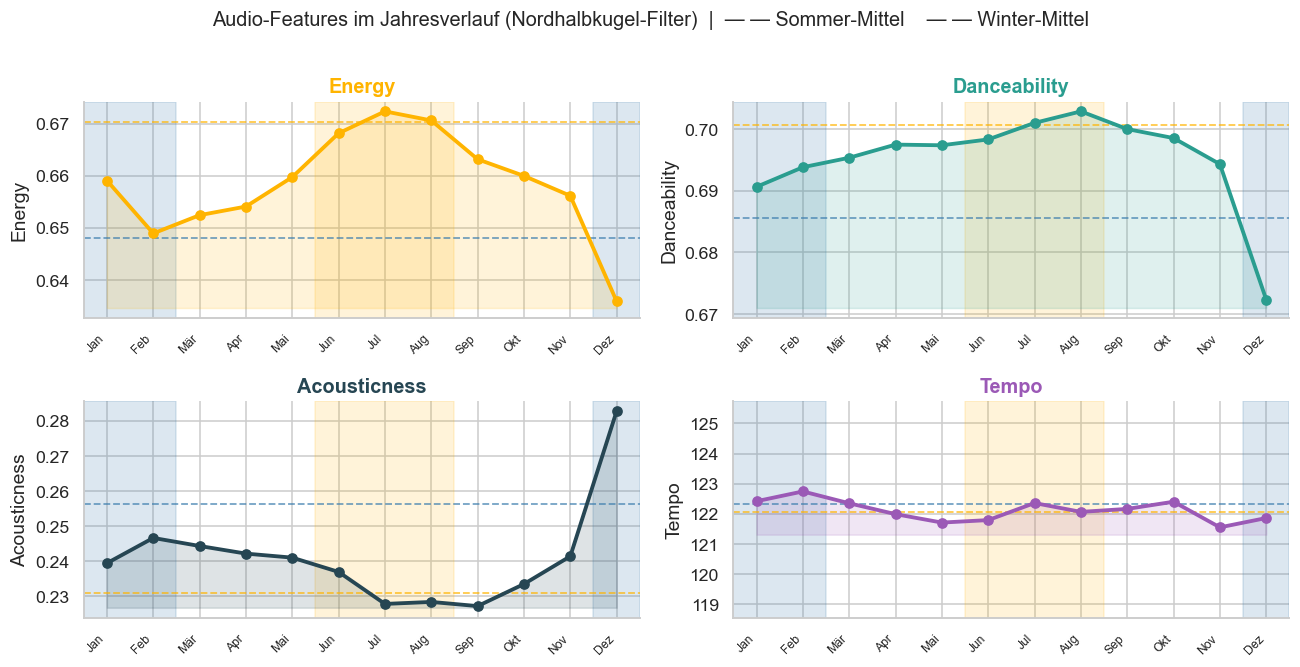

In [13]:
# --- Länder-Filter ---
suedhalb = {
    'Argentina', 'Australia', 'Chile', 'New Zealand',
    'Uruguay', 'South Africa', 'Bolivia', 'Peru'
}
aequator = {
    'Brazil', 'Colombia', 'Costa Rica', 'Ecuador', 'Guatemala',
    'Honduras', 'Indonesia', 'Malaysia', 'Philippines', 'Singapore',
    'El Salvador', 'Thailand', 'Vietnam', 'Dominican Republic',
    'Bahamas', 'India'
}
ausschliessen = suedhalb | aequator
spotify_nh = spotify[~spotify['country'].isin(ausschliessen)].copy()

print(f'Verbleibende Länder ({len(spotify_nh["country"].unique())}):')
print(sorted(spotify_nh['country'].unique()))
print(f'Zeilen: {len(spotify):,} → {len(spotify_nh):,} ({len(spotify_nh)/len(spotify)*100:.1f} %)')

# --- Vis 1 (NH): Audio-Features im Jahresverlauf ---
from matplotlib.ticker import MultipleLocator

features_nv = ['energy', 'danceability', 'acousticness', 'tempo']
labels_nv   = ['Energy', 'Danceability', 'Acousticness', 'Tempo']
farben_nv   = ['#FFB400', '#2A9D8F', '#264653', '#9B59B6']

monat_agg_nh = spotify_nh.groupby('month')[features_nv].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=False)
axes = axes.flatten()

for ax, feat, label, farbe in zip(axes, features_nv, labels_nv, farben_nv):
    y = monat_agg_nh[feat]

    ax.axvspan(5.5, 8.5,   color=FARBE_SOMMER, alpha=0.15)
    ax.axvspan(0.5, 2.5,   color=FARBE_WINTER, alpha=0.18)
    ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18)

    ax.fill_between(y.index, y, y.min() * 0.998, color=farbe, alpha=0.15)
    ax.plot(y.index, y, color=farbe, lw=2.5, marker='o', ms=6, zorder=3)

    s_mean = y.loc[[6, 7, 8]].mean()
    w_mean = y.loc[[12, 1, 2]].mean()
    ax.axhline(s_mean, color=FARBE_SOMMER, lw=1.2, ls='--', alpha=0.7)
    ax.axhline(w_mean, color=FARBE_WINTER,  lw=1.2, ls='--', alpha=0.7)

    ax.set_title(label, fontsize=13, fontweight='bold', color=farbe)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONATS_NAMEN, fontsize=8, rotation=45, ha='right')
    ax.set_xlim(0.5, 12.5)
    ax.set_ylabel(feat.capitalize())
    step = 1 if feat == 'tempo' else 0.01
    ax.yaxis.set_major_locator(MultipleLocator(step))
    if feat == 'tempo':
        ax.set_ylim(y.min() - 3, y.max() + 3)
    sns.despine(ax=ax)

fig.suptitle('Audio-Features im Jahresverlauf (Nordhalbkugel-Filter)  |  '
             '— — Sommer-Mittel    — — Winter-Mittel',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

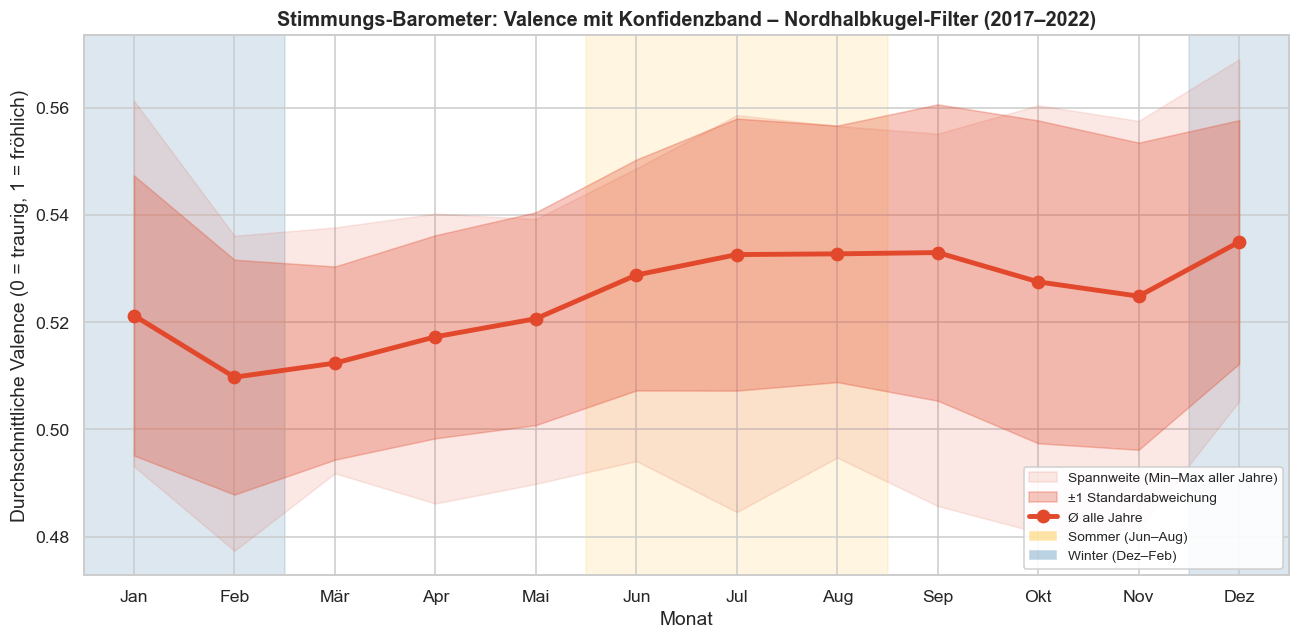

Monatliche Streuung (Nordhalbkugel-Filter):
  Jan  Ø=0.521  ±0.0261  [0.493 – 0.561]
  Feb  Ø=0.510  ±0.0219  [0.477 – 0.536]
  Mär  Ø=0.512  ±0.0180  [0.492 – 0.538]
  Apr  Ø=0.517  ±0.0189  [0.486 – 0.540]
  Mai  Ø=0.521  ±0.0198  [0.490 – 0.539]
  Jun  Ø=0.529  ±0.0215  [0.494 – 0.549]
  Jul  Ø=0.533  ±0.0254  [0.485 – 0.559]
  Aug  Ø=0.533  ±0.0239  [0.495 – 0.557]
  Sep  Ø=0.533  ±0.0276  [0.486 – 0.555]
  Okt  Ø=0.527  ±0.0301  [0.481 – 0.560]
  Nov  Ø=0.525  ±0.0286  [0.481 – 0.557]
  Dez  Ø=0.535  ±0.0227  [0.505 – 0.569]


In [14]:
# --- Vis 2 (NH): Valence-Stimmungsbarometer mit Schwankungsband ---
monat_jahr_nh = spotify_nh.groupby(['year', 'month'])['valence'].mean().reset_index()

monat_stats_nh = (monat_jahr_nh.groupby('month')['valence']
                  .agg(mittel='mean', streuung='std', vmin='min', vmax='max')
                  .reset_index())

x_nh      = monat_stats_nh['month']
mittel_nh = monat_stats_nh['mittel']
streu_nh  = monat_stats_nh['streuung']

fig, ax = plt.subplots(figsize=(12, 6))

ax.axvspan(5.5,  8.5,  color=FARBE_SOMMER, alpha=0.12, zorder=0)
ax.axvspan(11.5, 12.5, color=FARBE_WINTER, alpha=0.18, zorder=0)
ax.axvspan(0.5,  2.5,  color=FARBE_WINTER, alpha=0.18, zorder=0)

ax.fill_between(x_nh, monat_stats_nh['vmin'], monat_stats_nh['vmax'],
                color='#E2492C', alpha=0.12,
                label='Spannweite (Min–Max aller Jahre)', zorder=1)
ax.fill_between(x_nh, mittel_nh - streu_nh, mittel_nh + streu_nh,
                color='#E2492C', alpha=0.30,
                label='±1 Standardabweichung', zorder=2)
ax.plot(x_nh, mittel_nh, color='#E2492C', linewidth=3.2,
        marker='o', markersize=8, label='Ø alle Jahre', zorder=3)

from matplotlib.patches import Patch
legende_extra = [
    Patch(facecolor=FARBE_SOMMER, alpha=0.35, label='Sommer (Jun–Aug)'),
    Patch(facecolor=FARBE_WINTER, alpha=0.35, label='Winter (Dez–Feb)'),
]

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONATS_NAMEN)
ax.set_xlabel('Monat')
ax.set_ylabel('Durchschnittliche Valence (0 = traurig, 1 = fröhlich)')
ax.set_title('Stimmungs-Barometer: Valence mit Konfidenzband – Nordhalbkugel-Filter (2017–2022)')
ax.set_xlim(0.5, 12.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legende_extra,
          loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

print('Monatliche Streuung (Nordhalbkugel-Filter):')
for _, row in monat_stats_nh.iterrows():
    print(f'  {MONATS_NAMEN[int(row.month)-1]:>3}  '
          f'Ø={row.mittel:.3f}  ±{row.streuung:.4f}  '
          f'[{row.vmin:.3f} – {row.vmax:.3f}]')